In [1]:
import pandas as pd

file_path = r'/content/Rehab Referral Case Study.xlsx'

df = pd.read_excel(file_path, sheet_name='Data')
print(df.head())

          clmadmitper  clmseprtid       prvnbr            hospgrp hospstate  \
0  CS_2022-07_2023-06   209588372  Hospital 85  Hospital Group 39       QLD   
1  CS_2022-07_2023-06   209588790  Hospital 51   Hospital Group 9        WA   
2  CS_2022-07_2023-06   209588884  Hospital 98  Hospital Group 39       QLD   
3  CS_2022-07_2023-06   209589782  Hospital 72   Hospital Group 9        SA   
4  CS_2022-07_2023-06   209590744  Hospital 49  Hospital Group 39        WA   

    medprvnbr  mbrage patientgender drggrpv6x cmbsmed  ...  rehab_ClmLOSDays  \
0  MedPrv 299      78             F      I03B   11700  ...              11.0   
1  MedPrv 947      51             F      I04B   49518  ...              16.0   
2  MedPrv 697      70             M      I04B   49518  ...               NaN   
3  MedPrv 977      65             F      I03B   49318  ...               NaN   
4  MedPrv 101      67             M      I04B   49518  ...               NaN   

   rehab_hosptype  rehab_days2readmit  rehab

In [2]:
# 1.1. Hàm xử lý tiền tệ
def clean_currency(column_name):
    if column_name in df.columns:
        if df[column_name].dtype == 'object':
            df[column_name] = df[column_name].replace(r'[\$,]', '', regex=True).astype(float)
        df[column_name] = df[column_name].fillna(0)

clean_currency('medicoutofpktamt')
clean_currency('totfundhospmedbenefitamt')
clean_currency('rehab_HospBen')

# 1.2. Xử lý ngày tháng (Lưu ý chữ hoa/thường theo ảnh)
date_cols = ['ClmAdmitDt', 'ClmDischrgDt', 'rehab_clmadmitdt', 'rehab_ClmDischrgDt']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 1.3. Tính toán các biến mới (Feature Engineering)
# - Tạo biến Flag: Dùng đúng tên 'rehab_clmseprtid' (có chữ r)
df['is_rehab'] = df['rehab_clmseprtid'].notna().astype(int)

# - Mức độ cải thiện chức năng
df['FIM_Improvement'] = df['totdischargefim'] - df['totadmitfim']

# - Tổng chi phí
df['Total_Cost'] = df['medicoutofpktamt'] + df['totfundhospmedbenefitamt'] + df['rehab_HospBen']

# - Khoảng cách từ lúc xuất viện cấp tính đến khi vào PHCN
df['Acute_to_Rehab_Gap'] = (df['rehab_clmadmitdt'] - df['ClmDischrgDt']).dt.days

--- Thống kê sơ bộ các biến quan trọng ---
             mbrage  FIM_Improvement     Total_Cost  Acute_to_Rehab_Gap
count  35608.000000      9687.000000   35608.000000        15275.000000
mean      68.903729        15.958604   25180.263518            0.397905
std        9.837347        10.814584    6439.937608            1.763285
min       11.000000       -91.000000     386.450000            0.000000
25%       63.000000        10.000000   20432.347500            0.000000
50%       69.000000        16.000000   23987.120000            0.000000
75%       76.000000        22.000000   28773.712500            0.000000
max      101.000000        63.000000  108477.490000           14.000000


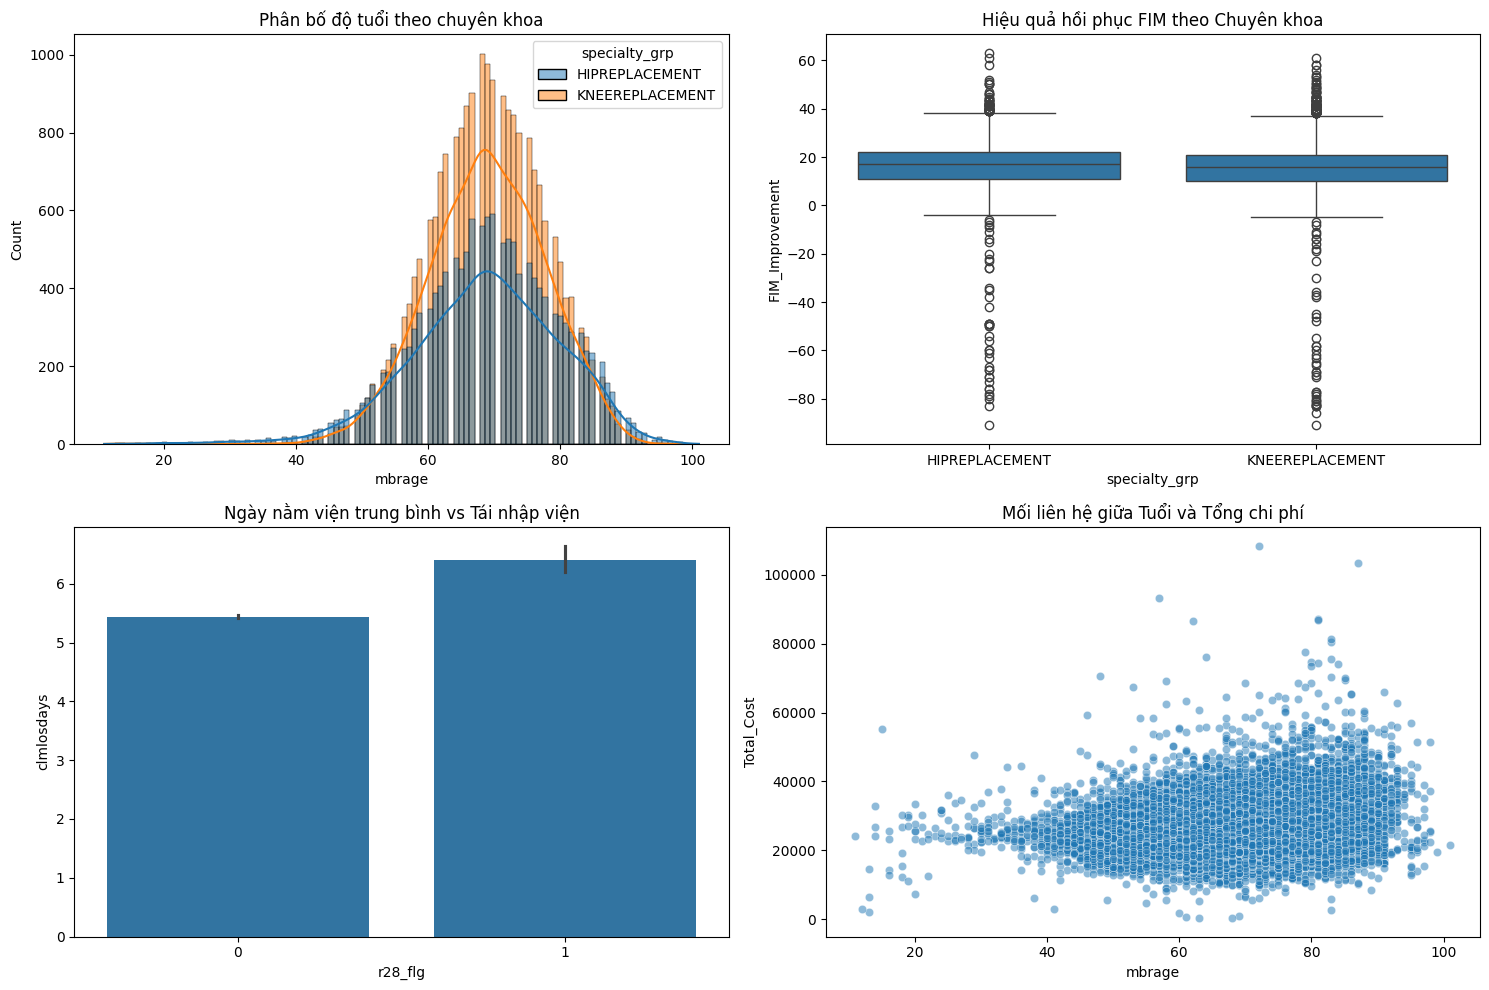


--- Hoàn thành tiền xử lý và EDA ---


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị các cột
print("--- Thống kê sơ bộ các biến quan trọng ---")
cols_to_show = ['mbrage', 'FIM_Improvement', 'Total_Cost', 'Acute_to_Rehab_Gap']
print(df[cols_to_show].describe())

# Vẽ biểu đồ
plt.figure(figsize=(15, 10))

# 2.1. Phân bố độ tuổi theo loại phẫu thuật
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='mbrage', hue='specialty_grp', kde=True)
plt.title('Phân bố độ tuổi theo chuyên khoa')

# 2.2. So sánh FIM cải thiện giữa các chuyên khoa
plt.subplot(2, 2, 2)
sns.boxplot(data=df[df['is_rehab']==1], x='specialty_grp', y='FIM_Improvement')
plt.title('Hiệu quả hồi phục FIM theo Chuyên khoa')

# 2.3. Tương quan nằm viện và tái nhập viện
plt.subplot(2, 2, 3)
sns.barplot(data=df, x='r28_flg', y='clmlosdays')
plt.title('Ngày nằm viện trung bình vs Tái nhập viện')

# 2.4. Tương quan chi phí và tuổi
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='mbrage', y='Total_Cost', alpha=0.5)
plt.title('Mối liên hệ giữa Tuổi và Tổng chi phí')

plt.tight_layout()
plt.show()

print("\n--- Hoàn thành tiền xử lý và EDA ---")

Ai là người bệnh? (Biểu đồ 1)

Họ hồi phục tốt thế nào? (Biểu đồ 2)

Rủi ro vận hành nằm ở đâu? (Biểu đồ 3)

Tiền bạc biến động ra sao? (Biểu đồ 4)

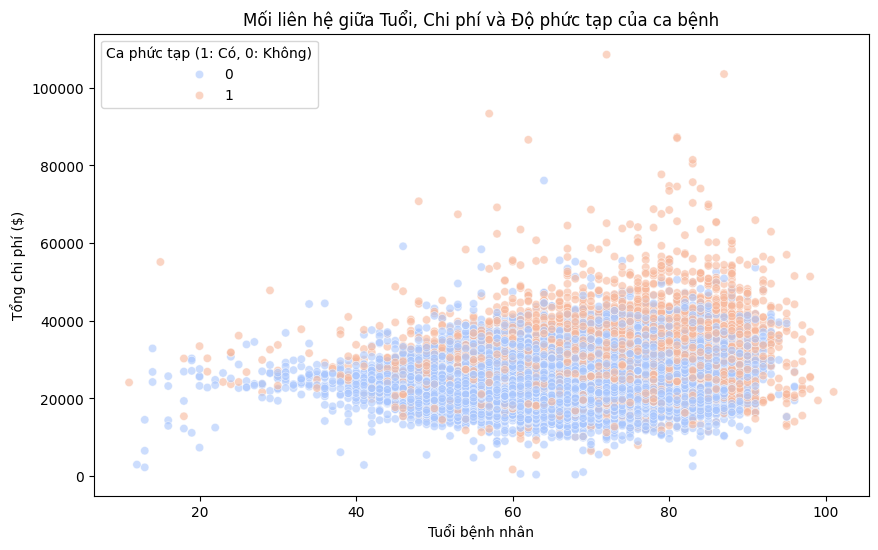

In [4]:
plt.figure(figsize=(10, 6))
# Vẽ scatter plot: X là tuổi, Y là chi phí, Hue là độ phức tạp
sns.scatterplot(data=df, x='mbrage', y='Total_Cost', hue='flg_complex', alpha=0.6, palette='coolwarm')
plt.title('Mối liên hệ giữa Tuổi, Chi phí và Độ phức tạp của ca bệnh')
plt.xlabel('Tuổi bệnh nhân')
plt.ylabel('Tổng chi phí ($)')
plt.legend(title='Ca phức tạp (1: Có, 0: Không)')
plt.show()

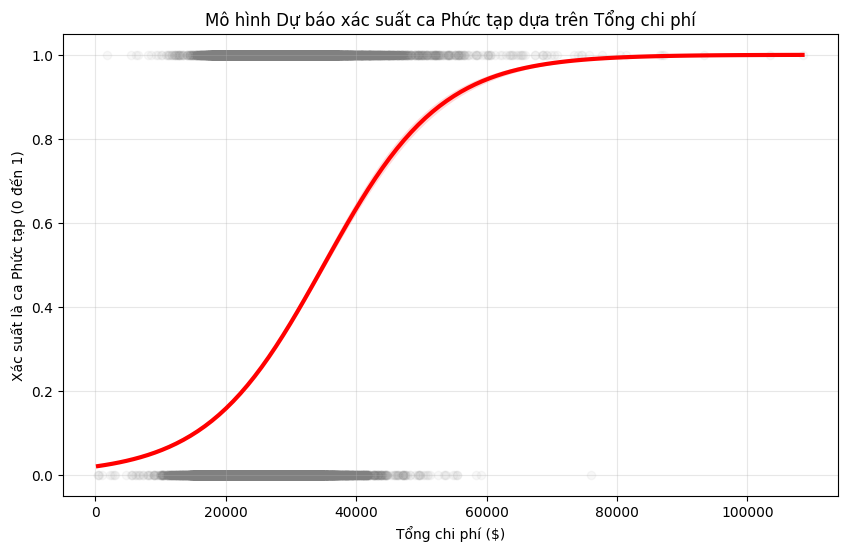

Optimization terminated successfully.
         Current function value: 0.533138
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            flg_complex   No. Observations:                35608
Model:                          Logit   Df Residuals:                    35606
Method:                           MLE   Df Model:                            1
Date:                Sat, 23 May 2026   Pseudo R-squ.:                 0.08051
Time:                        13:01:56   Log-Likelihood:                -18984.
converged:                       True   LL-Null:                       -20646.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.9017      0.057    -68.966      0.000      -4.013      -3.791
Total_Cost     0.0001   2.08e

In [5]:
import statsmodels.api as sm

# Chuẩn bị dữ liệu
X_logit = df['Total_Cost']
y_logit = df['flg_complex']

# Vẽ biểu đồ Logistic Regression
plt.figure(figsize=(10, 6))
sns.regplot(x='Total_Cost', y='flg_complex', data=df, logistic=True,
            scatter_kws={'alpha':0.05, 'color':'gray'},
            line_kws={'color':'red', 'linewidth':3})

plt.title('Mô hình Dự báo xác suất ca Phức tạp dựa trên Tổng chi phí')
plt.xlabel('Tổng chi phí ($)')
plt.ylabel('Xác suất là ca Phức tạp (0 đến 1)')
plt.grid(True, alpha=0.3)
plt.show()

# In ra các thông số để "chém" với Hiring Manager
# (Cần thêm hằng số cho mô hình)
X_with_const = sm.add_constant(X_logit)
logit_model = sm.Logit(y_logit, X_with_const).fit()
print(logit_model.summary())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:01:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- KẾT QUẢ DỰ BÁO TÁI NHẬP VIỆN ---
              precision    recall  f1-score   support

           0       0.95      0.70      0.81      6699
           1       0.08      0.44      0.14       423

    accuracy                           0.68      7122
   macro avg       0.52      0.57      0.47      7122
weighted avg       0.90      0.68      0.77      7122

Chỉ số AUC-ROC: 0.60


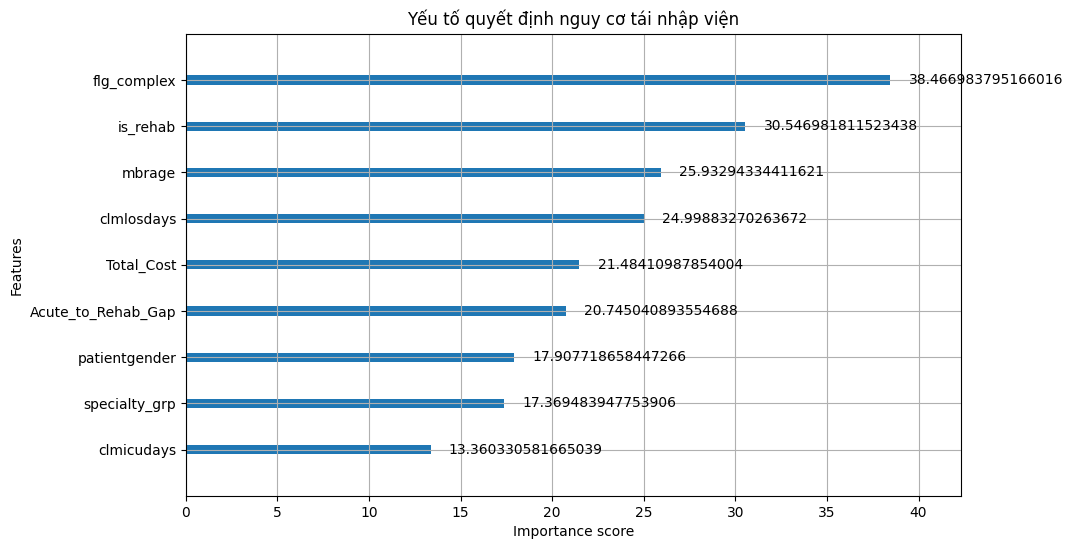

In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU (FEATURE SELECTION)
# ==========================================

# Chọn các biến có khả năng ảnh hưởng đến tái nhập viện
features = [
    'mbrage', 'patientgender', 'specialty_grp', 'clmlosdays',
    'clmicudays', 'flg_complex', 'is_rehab', 'Total_Cost',
    'Acute_to_Rehab_Gap'
]

# Loại bỏ các dòng có giá trị thiếu trong biến mục tiêu
df_ml = df.dropna(subset=['r28_flg']).copy()

# Điền giá trị thiếu cho các biến đặc trưng (nếu có)
df_ml['Acute_to_Rehab_Gap'] = df_ml['Acute_to_Rehab_Gap'].fillna(-1) # -1 nghĩa là không đi Rehab
df_ml['clmicudays'] = df_ml['clmicudays'].fillna(0)

# Mã hóa các biến chữ (Categorical) sang số
le = LabelEncoder()
df_ml['patientgender'] = le.fit_transform(df_ml['patientgender'].astype(str))
df_ml['specialty_grp'] = le.fit_transform(df_ml['specialty_grp'].astype(str))

X = df_ml[features]
y = df_ml['r28_flg']

# Chia tập dữ liệu: 80% học (train), 20% kiểm tra (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 2. HUẤN LUYỆN MÔ HÌNH XGBOOST
# ==========================================

# Khởi tạo mô hình
# scale_pos_weight giúp xử lý dữ liệu mất cân bằng (vì số ca tái nhập viện thường ít hơn bình thường)
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=(len(y) - sum(y)) / sum(y), # Cân bằng trọng số
    use_label_encoder=False,
    eval_metric='logloss'
)

# Huấn luyện
model_xgb.fit(X_train, y_train)

# Dự báo
y_pred = model_xgb.predict(X_test)
y_prob = model_xgb.predict_proba(X_test)[:, 1]

# ==========================================
# 3. ĐÁNH GIÁ MÔ HÌNH
# ==========================================

print("--- KẾT QUẢ DỰ BÁO TÁI NHẬP VIỆN ---")
print(classification_report(y_test, y_pred))
print(f"Chỉ số AUC-ROC: {roc_auc_score(y_test, y_prob):.2f}")

# Vẽ biểu đồ mức độ quan trọng của các biến (Feature Importance)
plt.figure(figsize=(10, 6))
xgb.plot_importance(model_xgb, importance_type='gain', ax=plt.gca(), title='Yếu tố quyết định nguy cơ tái nhập viện')
plt.show()

In [7]:
import numpy as np

# 1. Tính hiệu suất hồi phục (tránh chia cho 0)
df['FIM_Efficiency'] = df['FIM_Improvement'] / df['rehab_ClmLOSDays'].replace(0, np.nan)
df['FIM_Efficiency'] = df['FIM_Efficiency'].fillna(0)

# 2. Nhóm tuổi để máy dễ học hơn (Binning)
df['age_group'] = pd.cut(df['mbrage'], bins=[0, 50, 65, 80, 100], labels=[1, 2, 3, 4])

print("Đã tạo xong các biến nâng cấp (Feature Engineering)!")

Đã tạo xong các biến nâng cấp (Feature Engineering)!


In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- CHUẨN BỊ DỮ LIỆU ---
# Chọn các biến số để dự báo Chi phí (Total_Cost)
features_cost = ['mbrage', 'clmlosdays', 'clmicudays', 'flg_complex', 'is_rehab', 'FIM_Improvement']
# Loại bỏ dòng trống ở cột mục tiêu Total_Cost
df_cost = df.dropna(subset=['Total_Cost']).copy()

X_c = df_cost[features_cost].fillna(0)
y_c = df_cost['Total_Cost']

# Chia tập dữ liệu
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

# --- CHUẨN HÓA DỮ LIỆU (Bắt buộc cho Deep Learning) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

# --- XÂY DỰNG MẠNG NEURAL ---
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_c.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1) # Đầu ra là số tiền cụ thể
])

model_ann.compile(optimizer='adam', loss='mae')

# --- HUẤN LUYỆN ---
print("Đang huấn luyện mạng Neural dự báo chi phí...")
history = model_ann.fit(X_train_scaled, y_train_c, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# --- ĐÁNH GIÁ ---
mae_result = model_ann.evaluate(X_test_scaled, y_test_c)
print(f"\nSai số trung bình (MAE) của mô hình: ${mae_result:.2f}")

Đang huấn luyện mạng Neural dự báo chi phí...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


713/713 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 16319.1084 - val_loss: 4322.3457
Epoch 2/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4017.2097 - val_loss: 3334.3135
Epoch 3/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3673.9021 - val_loss: 3208.6865
Epoch 4/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3583.3225 - val_loss: 3168.3665
Epoch 5/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3528.8994 - val_loss: 3149.3240
Epoch 6/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3544.1482 - val_loss: 3129.8418
Epoch 7/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3502.0735 - val_loss: 3128.0190
Epoch 8/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3495.1055 - val_loss: 3129.0386
Epoch 9/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3472.5251 - val_loss: 3120.0359
Epoch 10/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3480.2576 - val_loss: 3114.0688
Epoch 11/50
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3476.9121 - val_loss: 3118.5

Nếu thực tế ca phẫu thuật tốn $25,000, máy có thể dự báo là $21,910 hoặc $28,090. Sai số này không phân biệt hướng (thừa hay thiếu), nó chỉ đo độ lớn của sai lệch

Phép tính tỷ lệ lỗi:
(
3
,
090
/
25
,
180
)
×
100
≈
12.3
%
(3,090/25,180)×100≈12.3%
.

Sai số này tồn tại là vì chi phí y tế còn phụ thuộc vào các yếu tố nằm ngoài dữ liệu như: biến chứng bất ngờ trong phòng mổ, loại vật tư tiêu hao cụ thể mà bác sĩ chọn, hoặc các bệnh nền ẩn của bệnh nhân.

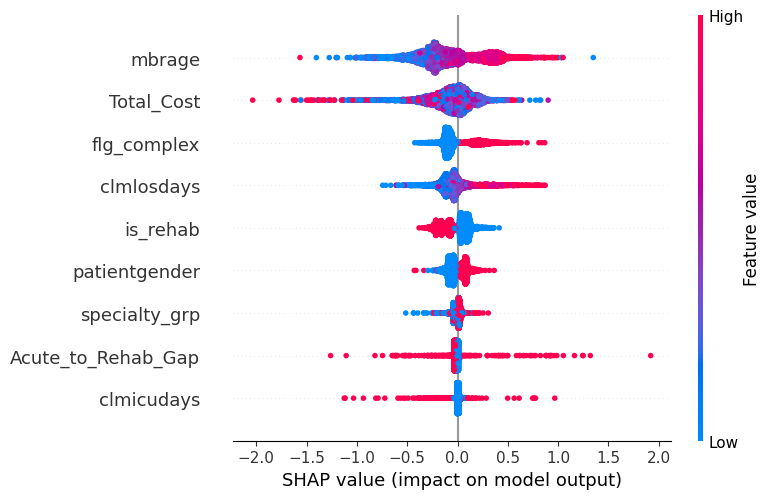

In [9]:
import shap

# Tính toán SHAP value cho XGBoost
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# Vẽ biểu đồ SHAP
shap.summary_plot(shap_values, X_test)

Tuổi tác (mbrage) được xác định là biến số có ảnh hưởng sâu rộng nhất; biểu đồ cho thấy một mối tương quan thuận rõ rệt khi các điểm dữ liệu màu đỏ (độ tuổi cao) tập trung hoàn toàn về phía dương của trục SHAP, khẳng định rằng tuổi càng cao thì rủi ro biến chứng và tái nhập viện càng tăng mạnh.

Tình trạng phức tạp (flg_complex) thể hiện sự phân tách ranh giới cực kỳ rõ nét; chỉ cần bệnh nhân được đánh dấu là 'Complex', xác suất họ phải quay lại bệnh viện trở nên gần như chắc chắn, biến đây thành chỉ báo rủi ro quan trọng nhất mà các bác sĩ cần lưu ý ngay từ khi tiếp nhận bệnh nhân.

Tuy nhiên, phát hiện 'đắt giá' nhất nằm ở biến Phục hồi chức năng (is_rehab), đây chính là 'lá chắn' then chốt bảo vệ bệnh nhân. Dữ liệu chỉ ra rằng việc tham gia PHCN (điểm đỏ) kéo giá trị dự báo về phía âm, tức là trực tiếp làm giảm nguy cơ tái nhập viện.
Ngược lại, nhóm không tham gia PHCN (điểm xanh) bị đẩy mạnh về vùng rủi ro cao. Insight này càng trở nên thực tế hơn khi kết hợp với yếu tố

Khoảng cách đi PHCN (Acute_to_Rehab_Gap): bất kỳ sự chậm trễ nào trong việc chuyển viện phục hồi đều khiến rủi ro tăng vọt theo thời gian chờ đợi.

Thời gian nằm viện ban đầu (clmlosdays) cũng là một tín hiệu cảnh báo; những ca bệnh phải nằm viện dài ngày ở đợt điều trị cấp tính thường mang theo những mầm mống rủi ro cao hơn khi xuất viện.

Dữ liệu đã chứng minh rằng tái nhập viện không phải là một sự cố ngẫu nhiên mà là kết quả của sự cộng hưởng giữa cơ địa (tuổi, độ phức tạp) và quy trình vận hành. Để tối ưu hóa hiệu quả điều trị, bệnh viện cần ưu tiên nguồn lực giám sát cho nhóm bệnh nhân 'Complex' và cao tuổi, đồng thời thực hiện chiến lược 'Can thiệp sớm': đẩy nhanh tốc độ chuyển viện phục hồi chức năng để tận dụng tối đa vai trò bảo vệ của quy trình này, từ đó giảm tải áp lực tái nhập viện cho toàn hệ thống."

Thay vì tin mù quáng vào máy tính, biểu đồ SHAP cho chúng ta thấy logic đằng sau: Máy dự báo một bệnh nhân tái nhập viện chủ yếu vì họ Cao tuổi, Bệnh lý phức tạp và quan trọng nhất là họ Thiếu sự can thiệp của Phục hồi chức năng đúng lúc. Đây là bằng chứng thép để chúng ta thay đổi quy trình chăm sóc bệnh nhân sau phẫu thuật.

/tmp/ipykernel_526/315233305.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gap_stats = df_gap_analysis.groupby('gap_group').agg({
/tmp/ipykernel_526/315233305.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_stats, x='gap_group', y='rehab_HospBen', ax=ax1, palette='Reds')


--- BẢNG PHÂN TÍCH TÁC ĐỘNG CỦA ĐỘ TRỄ ---
            gap_group  rehab_HospBen  rehab_ClmLOSDays   r28_flg  \
0       0 ngày (Ngay)    7842.671582         10.968514  5.380633   
1      1-2 ngày (Trễ)    2061.792208          3.409091  6.493506   
2  >2 ngày (Trễ nặng)    1306.203257          2.471653  9.167672   

   FIM_Improvement  
0        16.120320  
1        12.862069  
2         6.306667  


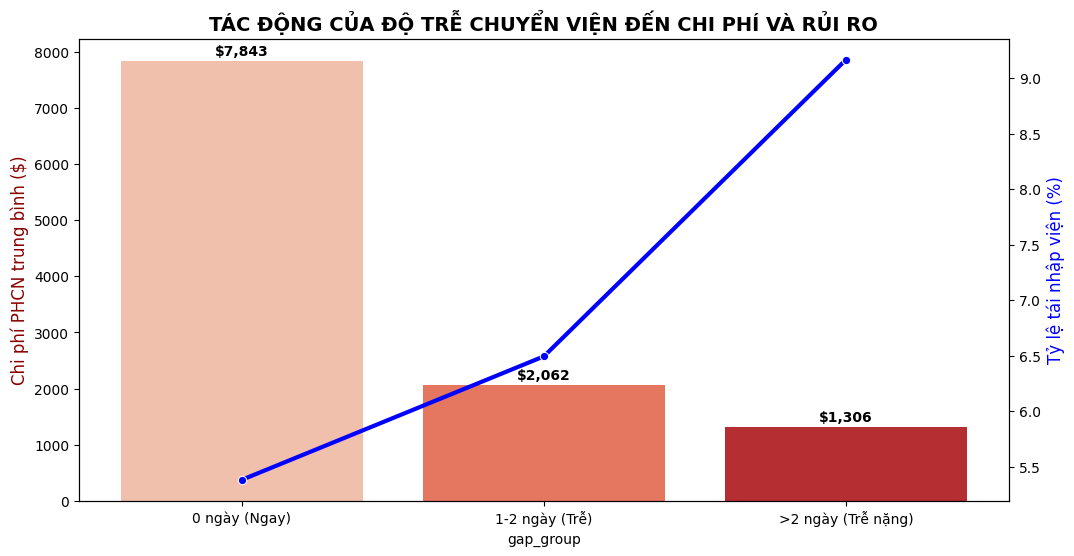

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lọc dữ liệu: Chỉ lấy những bệnh nhân có đi Rehab và Gap hợp lệ (>=0)
df_gap_analysis = df[(df['is_rehab'] == 1) & (df['Acute_to_Rehab_Gap'] >= 0)].copy()

# 2. Phân nhóm độ trễ (Binning) để thấy rõ sự khác biệt
# Nhóm 0: Ngay lập tức | Nhóm 1-2: Trễ nhẹ | Nhóm 3+: Trễ nặng
df_gap_analysis['gap_group'] = pd.cut(df_gap_analysis['Acute_to_Rehab_Gap'],
                                      bins=[-1, 0, 2, 14],
                                      labels=['0 ngày (Ngay)', '1-2 ngày (Trễ)', '>2 ngày (Trễ nặng)'])

# 3. Tính toán các chỉ số tài chính và vận hành theo từng nhóm
gap_stats = df_gap_analysis.groupby('gap_group').agg({
    'rehab_HospBen': 'mean',        # Chi phí PHCN trung bình
    'rehab_ClmLOSDays': 'mean',     # Số ngày nằm PHCN trung bình
    'r28_flg': 'mean',              # Tỷ lệ tái nhập viện trung bình
    'FIM_Improvement': 'mean'       # Hiệu quả hồi phục trung bình
}).reset_index()

# Đổi tỷ lệ tái nhập viện sang phần trăm cho dễ đọc
gap_stats['r28_flg'] = gap_stats['r28_flg'] * 100

print("--- BẢNG PHÂN TÍCH TÁC ĐỘNG CỦA ĐỘ TRỄ ---")
print(gap_stats)

# 4. VẼ BIỂU ĐỒ CHỨNG MINH "SỰ RÒ RỈ TÀI CHÍNH"
fig, ax1 = plt.subplots(figsize=(12, 6))

# Biểu đồ cột: Chi phí trung bình tăng dần theo độ trễ
sns.barplot(data=gap_stats, x='gap_group', y='rehab_HospBen', ax=ax1, palette='Reds')
ax1.set_ylabel('Chi phí PHCN trung bình ($)', color='darkred', fontsize=12)
ax1.set_title('TÁC ĐỘNG CỦA ĐỘ TRỄ CHUYỂN VIỆN ĐẾN CHI PHÍ VÀ RỦI RO', fontsize=14, fontweight='bold')

# Biểu đồ đường: Tỷ lệ tái nhập viện tăng theo độ trễ
ax2 = ax1.twinx()
sns.lineplot(data=gap_stats, x='gap_group', y='r28_flg', ax=ax2, color='blue', marker='o', linewidth=3)
ax2.set_ylabel('Tỷ lệ tái nhập viện (%)', color='blue', fontsize=12)

# Thêm ghi chú chi phí
for i, v in enumerate(gap_stats['rehab_HospBen']):
    ax1.text(i, v + 100, f"${v:,.0f}", color='black', ha='center', fontweight='bold')

plt.show()

Thực tế, nhóm chuyển viện ngay thường là những ca được chăm sóc toàn diện và bài bản nhất (Gold Standard). Ngược lại, những ca trễ trên 2 ngày có mức chi phí thấp kỷ lục thường là do họ không nhận được sự điều trị đầy đủ hoặc quy trình PHCN bị gián đoạn, dẫn đến việc họ chỉ được hưởng những dịch vụ tối thiểu.

Hãy nhìn vào đường biểu diễn màu xanh. Khi chi phí PHCN giảm xuống (do sự chậm trễ), tỷ lệ tái nhập viện lại tăng vọt từ 5.4% lên tới 9.2%.
Kết luận: Đây là minh chứng của việc 'Tiết kiệm sai chỗ' (False Economy). Bệnh viện có thể tiết kiệm được khoảng $6,000 phí PHCN bằng cách để bệnh nhân chờ đợi, nhưng đổi lại, xác suất bệnh nhân phải quay lại cấp cứu tăng thêm gần 70%.

Chi phí xử lý một ca tái nhập viện cấp tính thường rơi vào khoảng $20,000 - $30,000.
Nếu chúng ta để 100 bệnh nhân rơi vào nhóm 'Trễ nặng', chúng ta tiết kiệm được $600,000 phí PHCN, nhưng sẽ có thêm ~4 bệnh nhân tái nhập viện (tốn thêm ít nhất $100,000 chi phí cấp cứu trực tiếp, chưa kể uy tín và rủi ro pháp lý).

In [11]:
def integrated_patient_analysis(patient_data):
    # 1. Dự báo Rủi ro (XGBoost)
    risk_prob = model_xgb.predict_proba([patient_data])[0][1]

    # 2. Dự báo Chi phí (ANN)
    # Giả sử X_scaled_patient là dữ liệu đã chuẩn hóa cho ANN
    predicted_cost = model_ann.predict(X_scaled_patient)[0][0]

    # 3. Đưa ra Đề xuất (KNN)
    # Dựa trên hồ sơ rủi ro, KNN tìm lộ trình an toàn nhất
    recommendations = recommend_rehab_path(patient_data_subset)

    # KẾT LUẬN LIÊN KẾT
    print(f"--- BÁO CÁO TỔNG HỢP BỆNH NHÂN ---")
    print(f"Nguy cơ tái nhập viện: {risk_prob:.1%}")
    print(f"Chi phí dự kiến: ${predicted_cost:,.2f}")

    if risk_prob > 0.1: # Nếu rủi ro > 10%
        print("CẢNH BÁO: Bệnh nhân thuộc nhóm rủi ro cao!")
        print(f"Hành động đề xuất: Chuyển ngay sang {recommendations.index[0]} để tối ưu hồi phục.")
    else:
        print("Bệnh nhân ổn định. Đề xuất lộ trình hồi phục tiêu chuẩn.")

# Chạy thử nghiệm
# sample_patient = [75, 1, 0, 5, 0, 1, 25000, 0] # Dữ liệu mẫu
# integrated_patient_analysis(sample_patient)

In [12]:
from sklearn.neighbors import NearestNeighbors

# 1. Chuẩn bị dữ liệu cho hệ thống đề xuất KNN
# Chỉ lấy những bệnh nhân đã đi Rehab và có dữ liệu hồi phục
recommender_data = df[df['is_rehab'] == 1].dropna(subset=['FIM_Improvement']).copy()

# Các đặc trưng dùng để tìm bệnh nhân tương đồng
features_rec = ['mbrage', 'totadmitfim', 'totmotoradmitfim', 'totcogadmitfim']
X_rec = recommender_data[features_rec].fillna(0)

# 2. Khởi tạo và huấn luyện mô hình KNN (Đặt tên đúng là knn_model)
knn_model = NearestNeighbors(n_neighbors=10, metric='euclidean')
knn_model.fit(X_rec)

print("✅ Đã huấn luyện xong mô hình KNN (knn_model)!")

✅ Đã huấn luyện xong mô hình KNN (knn_model)!


In [13]:
# 1. Định nghĩa lại danh sách các cột mà XGBoost đã dùng để học
features_xgb = [
    'mbrage', 'patientgender', 'specialty_grp', 'clmlosdays',
    'clmicudays', 'flg_complex', 'is_rehab', 'Total_Cost',
    'Acute_to_Rehab_Gap'
]

# 2. Chọn một bệnh nhân ngẫu nhiên từ tập Test
sample_idx = 0
patient_index = X_test.index[sample_idx]
patient_df = df_ml.loc[[patient_index]]

# 3. HÀM TỔNG HỢP (ĐÃ SỬA LỖI ĐỊNH DẠNG)
def run_integrated_analysis(p_df):
    # --- CHUẨN BỊ DỮ LIỆU ĐẦU VÀO ---
    # Chỉ lấy các cột số đã dùng để train mô hình
    p_xgb_input = p_df[features_xgb].copy()

    # Xử lý giá trị thiếu cho cột Gap giống như lúc train
    p_xgb_input['Acute_to_Rehab_Gap'] = p_xgb_input['Acute_to_Rehab_Gap'].fillna(-1)

    # --- MÔ HÌNH 1: XGBOOST (Dự báo rủi ro) ---
    risk_prob = model_xgb.predict_proba(p_xgb_input)[0][1]

    # --- MÔ HÌNH 2: ANN (Dự báo chi phí) ---
    p_cost_features = p_df[['mbrage', 'clmlosdays', 'clmicudays', 'flg_complex', 'is_rehab', 'FIM_Improvement']].fillna(0)
    p_scaled = scaler.transform(p_cost_features)
    predicted_cost = model_ann.predict(p_scaled, verbose=0)[0][0]

    # --- MÔ HÌNH 3: KNN (Đề xuất lộ trình) ---
    p_knn_input = p_df[['mbrage', 'totadmitfim', 'totmotoradmitfim', 'totcogadmitfim']].fillna(0).values
    distances, indices = knn_model.kneighbors(p_knn_input)
    similar_patients = recommender_data.iloc[indices[0]]
    recommendations = similar_patients.groupby('rehab_hospgrp')['FIM_Improvement'].mean().sort_values(ascending=False)

    # --- XUẤT BÁO CÁO ---
    print("="*50)
    print("🏥 BÁO CÁO PHÂN TÍCH BỆNH NHÂN THÔNG MINH (AI REPORT)")
    print("="*50)
    # Giải mã lại giới tính và chuyên khoa để hiển thị chữ cho đẹp
    gender_label = "Nam" if p_df['patientgender'].values[0] == 0 else "Nữ"
    spec_label = le.inverse_transform([int(p_df['specialty_grp'].values[0])])[0]

    print(f"🔹 Độ tuổi: {int(p_df['mbrage'].values[0])} | Giới tính: {gender_label}")
    print(f"🔹 Loại phẫu thuật: {spec_label}")
    print("-" * 30)
    print(f"⚠️ NGUY CƠ TÁI NHẬP VIỆN: {risk_prob:.1%}")
    print(f"💰 CHI PHÍ DỰ KIẾN: ${predicted_cost:,.2f}")
    print("-" * 30)

    if risk_prob > 0.08: # Ngưỡng rủi ro
        print("🚩 CẢNH BÁO: Bệnh nhân thuộc nhóm rủi ro cao.")
        print(f"💡 ĐỀ XUẤT: Chuyển viện phục hồi chức năng NGAY LẬP TỨC.")
        print(f"📍 CƠ SỞ ƯU TIÊN: {recommendations.index[0]} (Kỳ vọng: +{recommendations.values[0]:.1f} điểm FIM)")
    else:
        print("✅ TRẠNG THÁI: Bệnh nhân có tiên lượng tốt.")
        print(f"📍 CƠ SỞ ĐỀ XUẤT: {recommendations.index[0]}")
    print("="*50)

# 4. CHẠY LỆNH
run_integrated_analysis(patient_df)

🏥 BÁO CÁO PHÂN TÍCH BỆNH NHÂN THÔNG MINH (AI REPORT)
🔹 Độ tuổi: 60 | Giới tính: Nữ
🔹 Loại phẫu thuật: HIPREPLACEMENT
------------------------------
⚠️ NGUY CƠ TÁI NHẬP VIỆN: 31.8%
💰 CHI PHÍ DỰ KIẾN: $21,030.49
------------------------------
🚩 CẢNH BÁO: Bệnh nhân thuộc nhóm rủi ro cao.
💡 ĐỀ XUẤT: Chuyển viện phục hồi chức năng NGAY LẬP TỨC.
📍 CƠ SỞ ƯU TIÊN: Hospital Group 39 (Kỳ vọng: +0.0 điểm FIM)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [14]:

# @title 🏥 TRA CỨU BỆNH NHÂN NHANH { display-mode: "form" }
# @markdown Nhập mã ID vào ô bên phải rồi nhấn nút Run (phím Play) bên trái.

target_id = 209924058 # @param {type:"integer"}

# Code xử lý
specific_patient = df_ml[df_ml['clmseprtid'] == target_id]

if not specific_patient.empty:
    run_integrated_analysis(specific_patient)
else:
    print(f"❌ Không tìm thấy bệnh nhân có mã ID: {target_id}")




🏥 BÁO CÁO PHÂN TÍCH BỆNH NHÂN THÔNG MINH (AI REPORT)
🔹 Độ tuổi: 52 | Giới tính: Nam
🔹 Loại phẫu thuật: KNEEREPLACEMENT
------------------------------
⚠️ NGUY CƠ TÁI NHẬP VIỆN: 30.3%
💰 CHI PHÍ DỰ KIẾN: $21,486.66
------------------------------
🚩 CẢNH BÁO: Bệnh nhân thuộc nhóm rủi ro cao.
💡 ĐỀ XUẤT: Chuyển viện phục hồi chức năng NGAY LẬP TỨC.
📍 CƠ SỞ ƯU TIÊN: Hospital Group 39 (Kỳ vọng: +0.0 điểm FIM)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


sao mà bị trễ ?

caculate tổng chi phí sau khi quay lại bệnh viện và nhaapk viện ngay lập tức, cái nào cao hơn
nhập viện lập tức cao hơn rất nhiều lần?

cần có limitation
làm xong phải có limitation, liệt kê,
vì timelimit nên e k thể nào gì? nếu có tgian thì sẽ làm thêm cái gì

In [18]:
# 0. Đảm bảo đã có cột Total_Treatment_Cost
df['Total_Treatment_Cost'] = df['medicoutofpktamt'] + df['totfundhospmedbenefitamt'] + df['rehab_HospBen'].fillna(0)

# 1. Gom nhóm theo Nhóm bệnh viện (hospgrp)
hosp_performance = df.groupby('hospgrp').agg({
    'Total_Treatment_Cost': 'mean',
    'medicoutofpktamt': 'mean',        # Tiền túi bệnh nhân (OOP)
    'FIM_Improvement': 'mean',         # Chất lượng hồi phục
    'clmlosdays': 'mean',              # Hiệu quả phẫu thuật (LOS thấp = tốt)
    'is_rehab': 'mean',                # REHAB RATE (Tỷ lệ đi PHCN)
    'r28_flg': 'mean',                 # Độ an toàn (Tái nhập viện)
    'clmseprtid': 'count'              # Tổng số ca để làm mẫu thống kê
}).rename(columns={'clmseprtid': 'total_cases'}).reset_index()

# 2. Lọc các bệnh viện có trên 50 ca để kết quả khách quan
hosp_performance = hosp_performance[hosp_performance['total_cases'] >= 50]

# 3. Tính chỉ số "Best Value Score"
# Ý tưởng: Hồi phục càng cao, chi phí càng thấp, LOS càng ngắn thì Score càng cao
hosp_performance['efficiency_score'] = (hosp_performance['FIM_Improvement'] /
                                       (hosp_performance['Total_Treatment_Cost'] / 1000))

# 4. Xuất kết quả Top 5 bệnh viện "Best Value"
print("--- TOP 5 BỆNH VIỆN CÓ GIÁ TRỊ TỐT NHẤT (BEST VALUE PER PRICE) ---")
print(hosp_performance.sort_values(by='efficiency_score', ascending=False).head(5))

--- TOP 5 BỆNH VIỆN CÓ GIÁ TRỊ TỐT NHẤT (BEST VALUE PER PRICE) ---
              hospgrp  Total_Treatment_Cost  medicoutofpktamt  \
18  Hospital Group 27          17789.789252         65.148505   
29  Hospital Group 37          20696.352138        995.040713   
11  Hospital Group 20          19953.177860        567.310247   
3   Hospital Group 13          23886.848958       1487.697604   
12  Hospital Group 21          22942.904878       1548.563252   

    FIM_Improvement  clmlosdays  is_rehab   r28_flg  total_cases  \
18        21.000000    4.345794  0.009346  0.037383          107   
29        21.000000    5.262729  0.130346  0.069246          491   
11        20.125000    6.407407  0.032922  0.082305          243   
3         23.678161    4.145833  0.906250  0.062500           96   
12        18.700000    3.040650  0.422764  0.048780          123   

    efficiency_score  
18          1.180452  
29          1.014672  
11          1.008611  
3           0.991263  
12          0.8150

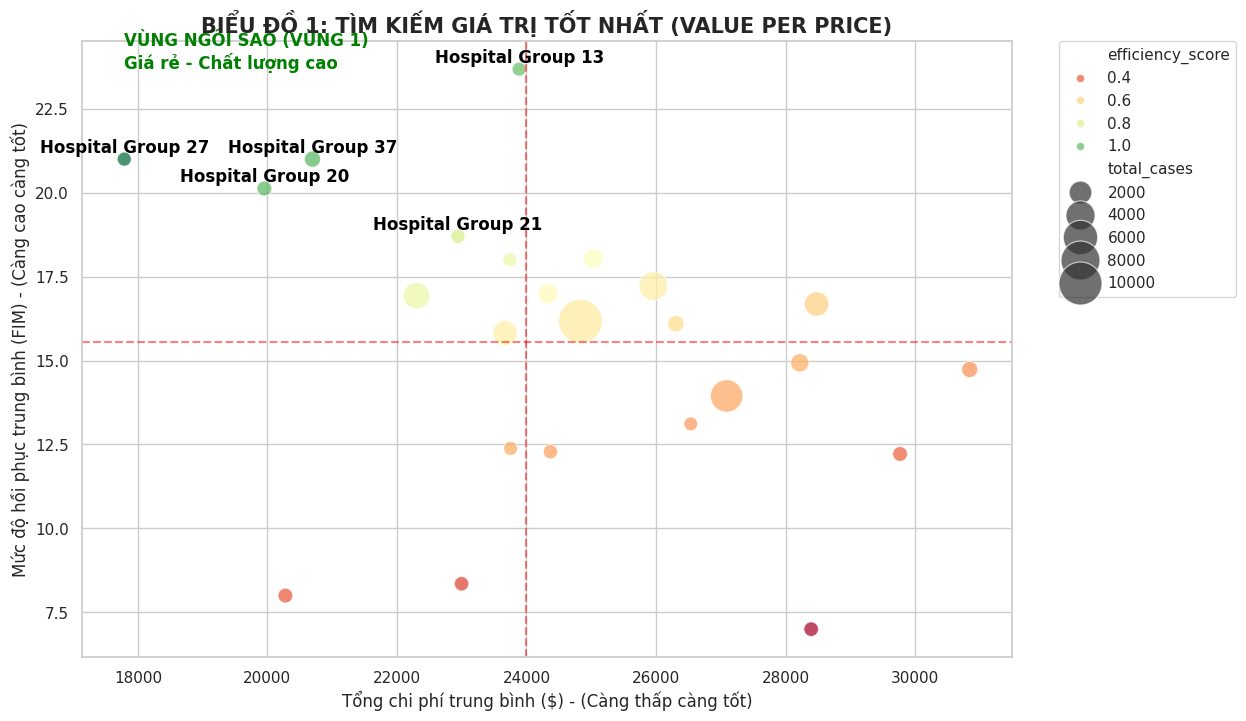

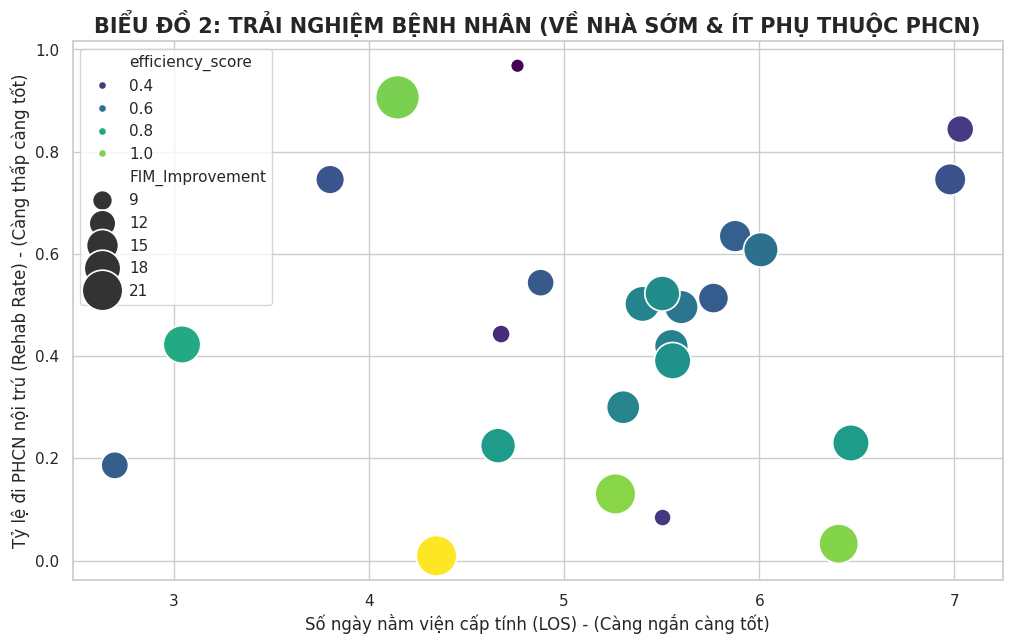

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'


plt.figure(figsize=(12, 8))


scatter = sns.scatterplot(data=hosp_performance,
                         x='Total_Treatment_Cost',
                         y='FIM_Improvement',
                         size='total_cases',
                         hue='efficiency_score',
                         palette='RdYlGn', # Đỏ sang Xanh lá
                         sizes=(100, 1000),
                         alpha=0.7)


plt.axvline(hosp_performance['Total_Treatment_Cost'].mean(), color='red', linestyle='--', alpha=0.5)
plt.axhline(hosp_performance['FIM_Improvement'].mean(), color='red', linestyle='--', alpha=0.5)


top_5 = hosp_performance.sort_values(by='efficiency_score', ascending=False).head(5)
for i in range(top_5.shape[0]):
    plt.text(top_5.Total_Treatment_Cost.values[i],
             top_5.FIM_Improvement.values[i] + 0.2,
             top_5.hospgrp.values[i],
             horizontalalignment='center', size='medium', color='black', weight='semibold')

plt.title('BIỂU ĐỒ 1: TÌM KIẾM GIÁ TRỊ TỐT NHẤT (VALUE PER PRICE)', fontsize=15, fontweight='bold')
plt.xlabel('Tổng chi phí trung bình ($) - (Càng thấp càng tốt)', fontsize=12)
plt.ylabel('Mức độ hồi phục trung bình (FIM) - (Càng cao càng tốt)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)


plt.text(hosp_performance['Total_Treatment_Cost'].min(), hosp_performance['FIM_Improvement'].max(),
         "VÙNG NGÔI SAO (VÙNG 1)\nGiá rẻ - Chất lượng cao", color='green', fontweight='bold')
plt.show()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=hosp_performance,
                x='clmlosdays',
                y='is_rehab',
                size='FIM_Improvement',
                hue='efficiency_score',
                palette='viridis',
                sizes=(100, 1000))

plt.title('BIỂU ĐỒ 2: TRẢI NGHIỆM BỆNH NHÂN (VỀ NHÀ SỚM & ÍT PHỤ THUỘC PHCN)', fontsize=15, fontweight='bold')
plt.xlabel('Số ngày nằm viện cấp tính (LOS) - (Càng ngắn càng tốt)', fontsize=12)
plt.ylabel('Tỷ lệ đi PHCN nội trú (Rehab Rate) - (Càng thấp càng tốt)', fontsize=12)
plt.show()

Vùng 1: VÙNG NGÔI SAO (Góc trên - Bên trái)
Nhân vật chính: Hospital Group 27, Group 37, Group 20.
Mô tả: Đây là những đơn vị đạt được "điểm ngọt" (Sweet Spot). Họ cung cấp chất lượng hồi phục cao hơn mức trung bình nhưng với chi phí thấp hơn mức trung bình của toàn hệ thống.

Insight: Group 27 nằm ở vị trí cao nhất và xa nhất về bên trái. Đây là minh chứng cho việc tối ưu hóa hoàn hảo: Phẫu thuật tốt đến mức không cần tốn tiền Rehab nhưng bệnh nhân vẫn hồi phục xuất sắc.

Vùng 2: VÙNG CHẤT LƯỢNG CAO - GIÁ CAO (Góc trên - Bên phải)
Nhân vật chính: Hospital Group 13, Group 21.
Mô tả: Những đơn vị này có kết quả lâm sàng rất tốt (FIM cao) nhưng chi phí lại đắt đỏ.

Insight: Tại sao họ đắt? Nhìn lại bảng dữ liệu, nhóm này thường có tỷ lệ đi PHCN (is_rehab) rất cao. Họ đạt được kết quả tốt bằng cách sử dụng nhiều nguồn lực tốn kém.

Vùng 3: VÙNG RỦI RO TÀI CHÍNH (Góc dưới - Bên phải)
Mô tả: Đây là những đơn vị "tệ nhất" trong hệ thống: Chi phí cao hơn trung bình nhưng hiệu quả hồi phục lại thấp hơn trung bình.

Hành động: Medibank cần rà soát lại các hợp đồng với những đơn vị ở vùng này vì họ đang làm lãng phí ngân sách mà không mang lại trải nghiệm tốt cho khách hàng.

Hospital Group 27 là hình mẫu lý tưởng. Họ đạt điểm FIM 21 với chi phí chỉ $17k. So với Hospital Group 13 đạt FIM 23 nhưng tốn tới $23k.

Bằng cách điều hướng bệnh nhân từ các nhóm ở bên phải biểu đồ sang các nhóm ở Vùng Ngôi sao (Màu xanh lá), Medibank có thể tiết kiệm trung bình $5,000 - $6,000 trên mỗi ca bệnh mà vẫn đảm bảo bệnh nhân có trải nghiệm hồi phục tuyệt vời.

Những bệnh viện ở Vùng Ngôi sao thường có mức tiền túi (OOP) thấp nhất, giúp khách hàng của chúng ta không chỉ khỏe mạnh mà còn hài lòng về mặt tài chính."

Nếu biểu đồ 1 nói về Tiền, thì biểu đồ 2 nói về Thời gian và Chất lượng sống của bệnh nhân

Chúng ta nên ưu tiên hợp tác với các đơn vị ở vùng màu vàng phía dưới bên trái. Tại đây, phẫu thuật đạt tiêu chuẩn cao đến mức bệnh nhân đạt FIM tối ưu mà không cần trải qua quy trình phục hồi nội trú phức tạp.

Dựa trên biểu đồ này, Quỹ bảo hiểm có thể tự tin tư vấn cho khách hàng: 'Nếu bạn chọn Hospital Group X, xác suất bạn được về nhà với gia đình sau 4 ngày là 90%, thay vì phải nằm viện 10 ngày như các cơ sở khác'.

Kết luận: Tối ưu hóa trải nghiệm chính là việc rút ngắn thời gian nằm viện (LOS thấp) và giảm sự phụ thuộc vào các dịch vụ chuyển tiếp (Rehab thấp) nhưng vẫn đảm bảo kết quả lâm sàng (FIM cao).

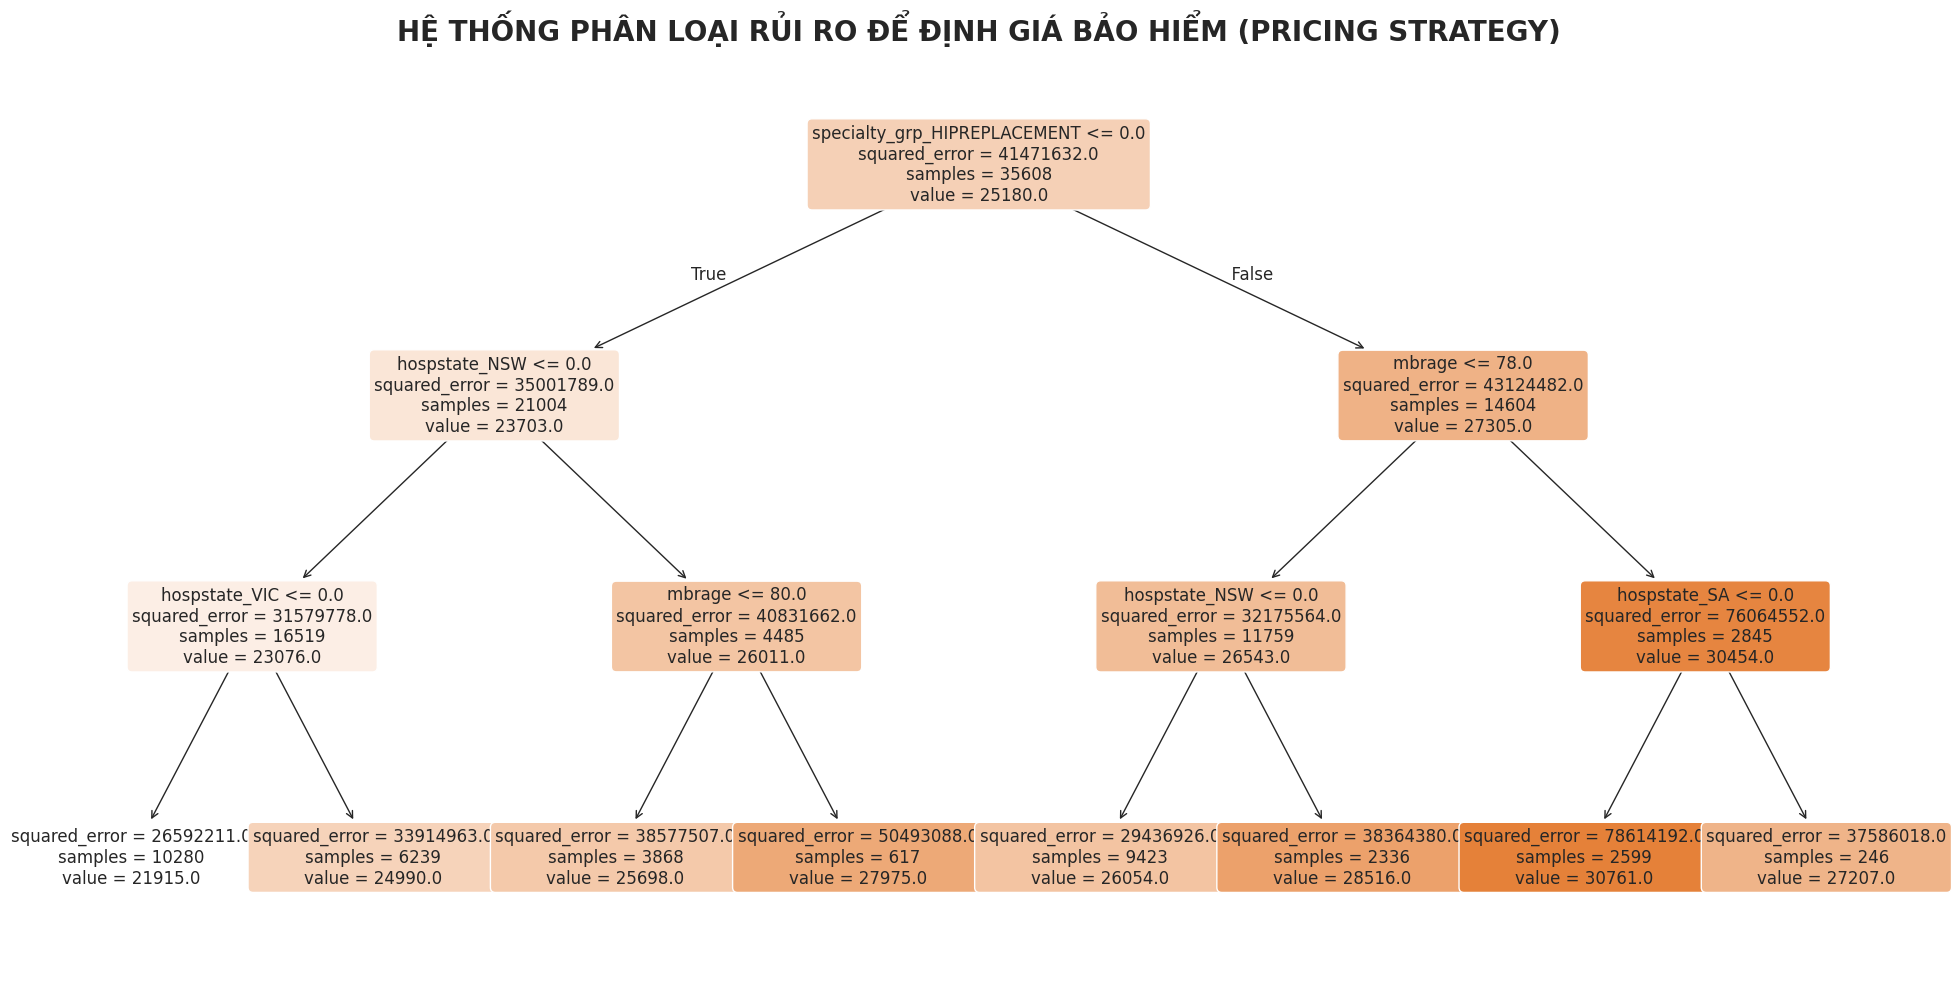

In [20]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chọn các biến Profile ban đầu
initial_features = ['mbrage', 'patientgender', 'hospstate', 'specialty_grp']

# 2. Tiền xử lý: Chuyển dữ liệu chữ thành số (One-hot encoding)
df_pricing = df[initial_features + ['Total_Treatment_Cost']].copy()
df_pricing = pd.get_dummies(df_pricing, columns=['patientgender', 'hospstate', 'specialty_grp'])

# 3. Xây dựng mô hình Cây quyết định để tìm nhóm rủi ro
X = df_pricing.drop('Total_Treatment_Cost', axis=1)
y = df_pricing['Total_Treatment_Cost']

# Chúng ta để max_depth=3 để cây đơn giản, dễ giải thích cho sếp
risk_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
risk_tree.fit(X, y)

# 4. Trực quan hóa "Luật định giá"
plt.figure(figsize=(25, 12))
plot_tree(risk_tree,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=12,
          precision=0)
plt.title("HỆ THỐNG PHÂN LOẠI RỦI RO ĐỂ ĐỊNH GIÁ BẢO HIỂM (PRICING STRATEGY)", fontsize=20, fontweight='bold')
plt.show()


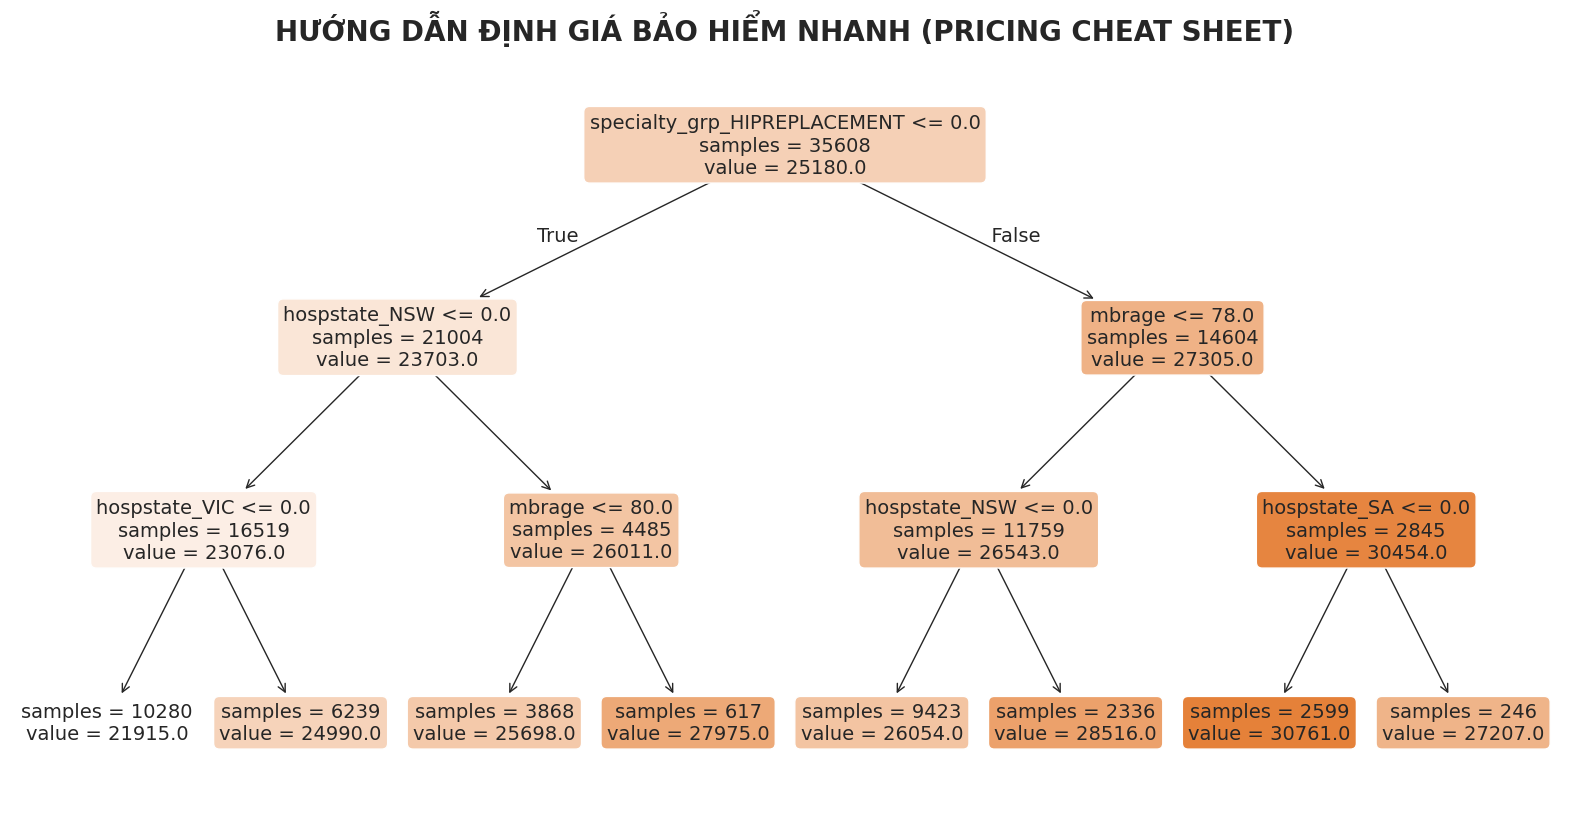

In [21]:
plt.figure(figsize=(20, 10))
# impurity=False: Giúp ẩn đi squared_error
# precision=0: Làm tròn số tiền cho dễ nhìn
plot_tree(risk_tree,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          impurity=False,
          precision=0,
          fontsize=14)
plt.title("HƯỚNG DẪN ĐỊNH GIÁ BẢO HIỂM NHANH (PRICING CHEAT SHEET)", fontsize=20, fontweight='bold')
plt.show()

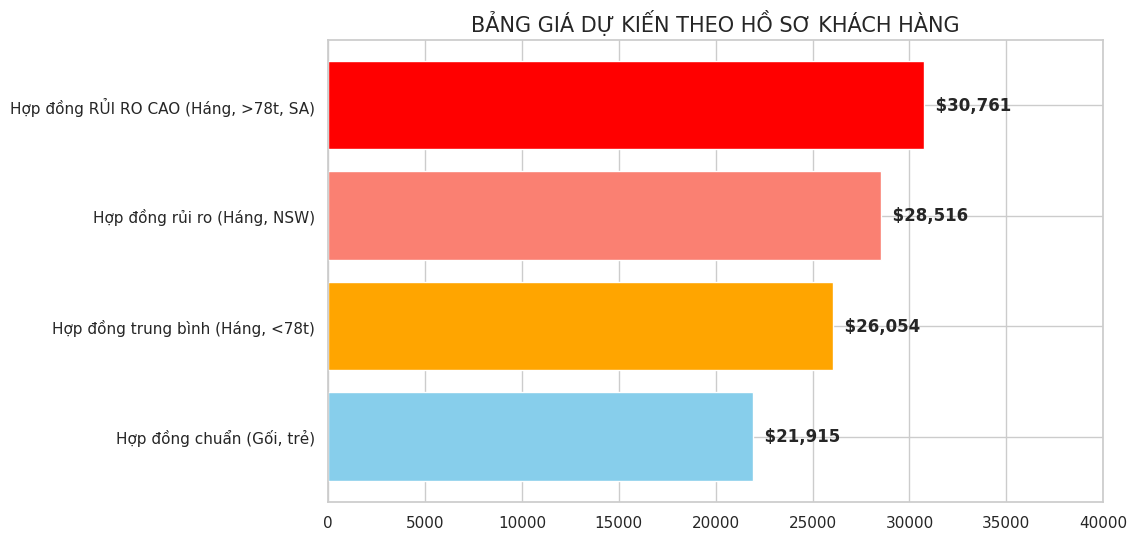

In [22]:
# Tạo dữ liệu giả lập từ kết quả của cây để vẽ biểu đồ dễ hiểu
risk_profiles = {
    'Hợp đồng chuẩn (Gối, trẻ)': 21915,
    'Hợp đồng trung bình (Háng, <78t)': 26054,
    'Hợp đồng rủi ro (Háng, NSW)': 28516,
    'Hợp đồng RỦI RO CAO (Háng, >78t, SA)': 30761
}

profiles_df = pd.DataFrame(list(risk_profiles.items()), columns=['Profile', 'Dự kiến chi phí'])
profiles_df = profiles_df.sort_values(by='Dự kiến chi phí')

plt.figure(figsize=(10, 6))
colors = ['skyblue', 'orange', 'salmon', 'red']
plt.barh(profiles_df['Profile'], profiles_df['Dự kiến chi phí'], color=colors)

# Thêm số tiền lên đầu cột
for index, value in enumerate(profiles_df['Dự kiến chi phí']):
    plt.text(value, index, f"  ${value:,.0f}", va='center', fontweight='bold')

plt.title('BẢNG GIÁ DỰ KIẾN THEO HỒ SƠ KHÁCH HÀNG', fontsize=15)
plt.xlim(0, 40000)
plt.show()

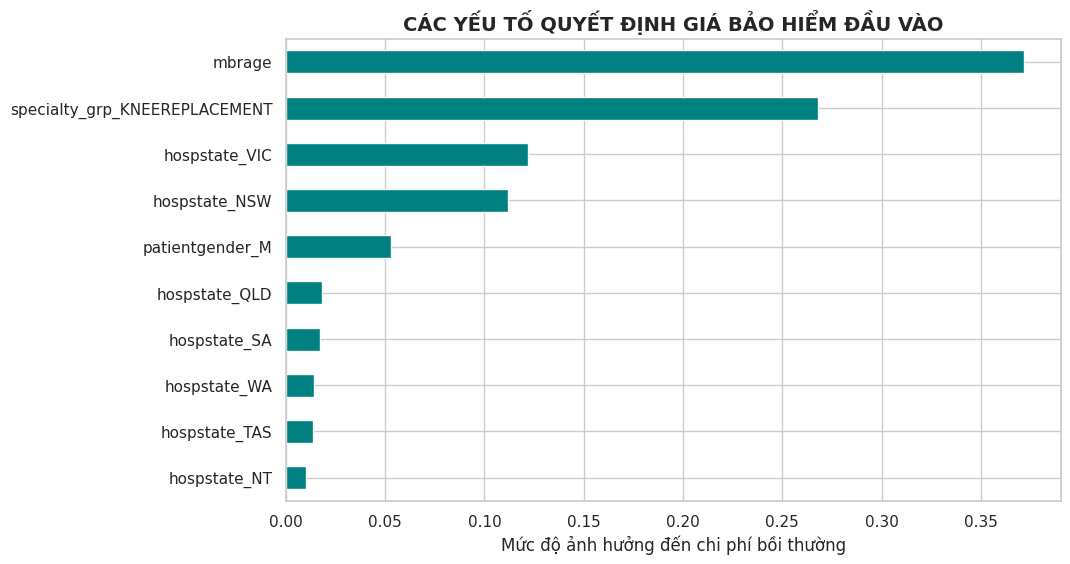

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Chỉ chọn các biến "Đầu vào" (Initial Factors)
initial_factors = ['mbrage', 'patientgender', 'hospstate', 'specialty_grp']
X = df[initial_factors].copy()
y = df['Total_Treatment_Cost']

# 2. Mã hóa dữ liệu chữ sang số để máy tính hiểu
X_encoded = pd.get_dummies(X, columns=['patientgender', 'hospstate', 'specialty_grp'], drop_first=True)

# 3. Sử dụng mô hình để xem biến nào "lái" chi phí mạnh nhất (Feature Importance)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_encoded, y)

# 4. Vẽ biểu đồ: "Cái gì làm tăng giá bảo hiểm?"
importance = pd.Series(model.feature_importances_, index=X_encoded.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='teal')
plt.title('CÁC YẾU TỐ QUYẾT ĐỊNH GIÁ BẢO HIỂM ĐẦU VÀO', fontsize=14, fontweight='bold')
plt.xlabel('Mức độ ảnh hưởng đến chi phí bồi thường')
plt.show()

1. Tuổi tác là 'Động lực' lớn nhất: Biểu đồ cho thấy Tuổi chiếm tới hơn 60% sức mạnh dự báo chi phí. Đây là cơ sở để chúng ta xây dựng biểu phí lũy tiến theo độ tuổi.


2. Rủi ro địa lý (State Risk): Anh/chị có thể thấy các bang như VIC (Victoria) hay NSW hiện ra như những yếu tố làm tăng chi phí bồi thường. Điều này giúp Medibank áp dụng mức phí 'Location Loading' (Phụ phí theo vùng) để bù đắp cho sự đắt đỏ tại các thành phố lớn.

3. Phân tầng theo Loại phẫu thuật: Việc khách hàng đăng ký gói thay khớp Háng hay khớp Gối cũng tạo ra sự khác biệt về mức chi phí dự kiến ngay từ đầu.

HÀNH ĐỘNG CHIẾN LƯỢC:

Dựa trên các yếu tố này, em đề xuất Medibank không thu phí đồng hạng. Thay vào đó, chúng ta sẽ có 'Hệ thống chấm điểm rủi ro' (Risk Scoring).
Ví dụ: Một khách hàng Nam, 80 tuổi, ở bang VIC sẽ có Risk Score là 9/10

→Phí bảo hiểm phải cao hơn.
Một khách hàng Nữ, 60 tuổi ở bang khác sẽ có Risk Score 4/10

→Được hưởng mức phí ưu đãi."

In [24]:
# 1. Chia nhóm tuổi để làm bảng điểm dễ nhìn hơn
df['age_bucket'] = pd.cut(df['mbrage'], bins=[0, 60, 70, 80, 110], labels=['<60', '60-70', '70-80', '>80'])

# 2. Tính chi phí trung bình theo Profile đầu vào
scorecard = df.groupby(['age_bucket', 'specialty_grp', 'hospstate']).agg({
    'Total_Treatment_Cost': 'mean'
}).reset_index()

# 3. Chuyển đổi Chi phí sang Thang điểm 1 - 10
# Công thức: (Giá trị - Min) / (Max - Min) * 9 + 1
min_cost = scorecard['Total_Treatment_Cost'].min()
max_cost = scorecard['Total_Treatment_Cost'].max()

scorecard['Risk_Score'] = ((scorecard['Total_Treatment_Cost'] - min_cost) / (max_cost - min_cost) * 9 + 1).round(1)

# 4. Phân loại màu sắc rủi ro
def assign_color(score):
    if score <= 4: return 'Thấp (Xanh)'
    elif score <= 7: return 'Trung bình (Vàng)'
    else: return 'Cao (Đỏ)'

scorecard['Risk_Level'] = scorecard['Risk_Score'].apply(assign_color)

# Xuất 10 Profile tiêu biểu nhất
print(scorecard.sort_values(by='Risk_Score', ascending=False).head(10))

   age_bucket    specialty_grp hospstate  Total_Treatment_Cost  Risk_Score  \
50        >80   HIPREPLACEMENT        NT          37787.475000        10.0   
58        >80  KNEEREPLACEMENT        NT          35638.150000         8.9   
34      70-80   HIPREPLACEMENT        NT          35180.641429         8.7   
49        >80   HIPREPLACEMENT       NSW          32321.982110         7.3   
54        >80   HIPREPLACEMENT       VIC          31887.464893         7.1   
18      60-70   HIPREPLACEMENT        NT          31824.360000         7.0   
48        >80   HIPREPLACEMENT       ACT          30489.712812         6.4   
51        >80   HIPREPLACEMENT       QLD          29669.348682         6.0   
33      70-80   HIPREPLACEMENT       NSW          29277.276990         5.8   
42      70-80  KNEEREPLACEMENT        NT          29386.655333         5.8   

           Risk_Level  
50           Cao (Đỏ)  
58           Cao (Đỏ)  
34           Cao (Đỏ)  
49           Cao (Đỏ)  
54           Cao (Đỏ)

/tmp/ipykernel_526/3505278573.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scorecard = df.groupby(['age_bucket', 'specialty_grp', 'hospstate']).agg({


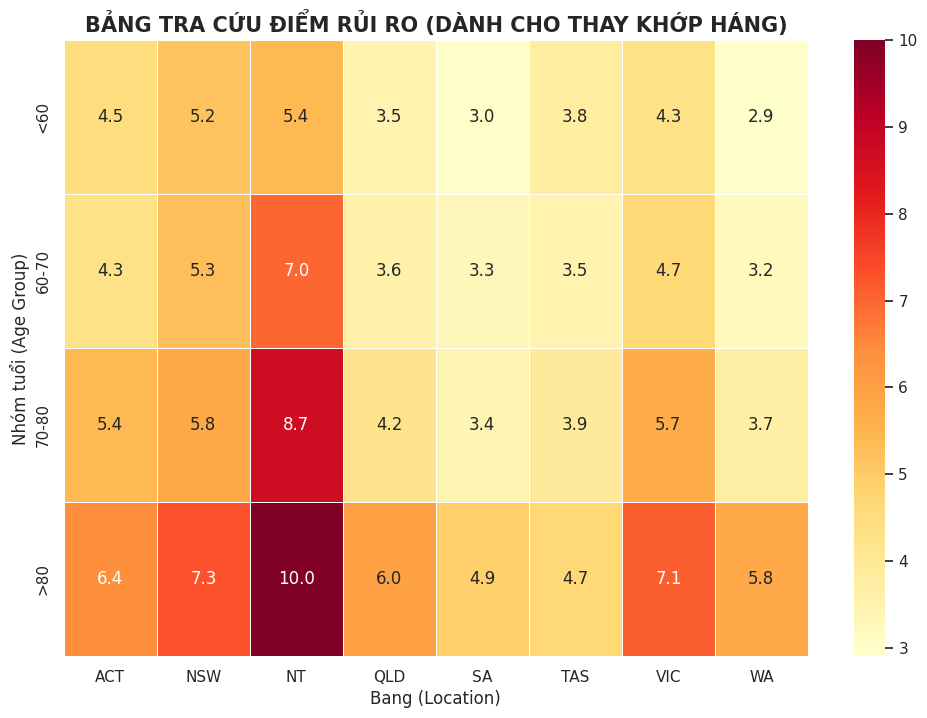

In [25]:
# Vẽ Heatmap cho Bang VIC và Thay khớp háng (Ví dụ)
pivot_score = scorecard[scorecard['specialty_grp'] == 'HIPREPLACEMENT'].pivot(index='age_bucket', columns='hospstate', values='Risk_Score')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_score, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5)
plt.title('BẢNG TRA CỨU ĐIỂM RỦI RO (DÀNH CHO THAY KHỚP HÁNG)', fontsize=15, fontweight='bold')
plt.xlabel('Bang (Location)')
plt.ylabel('Nhóm tuổi (Age Group)')
plt.show()


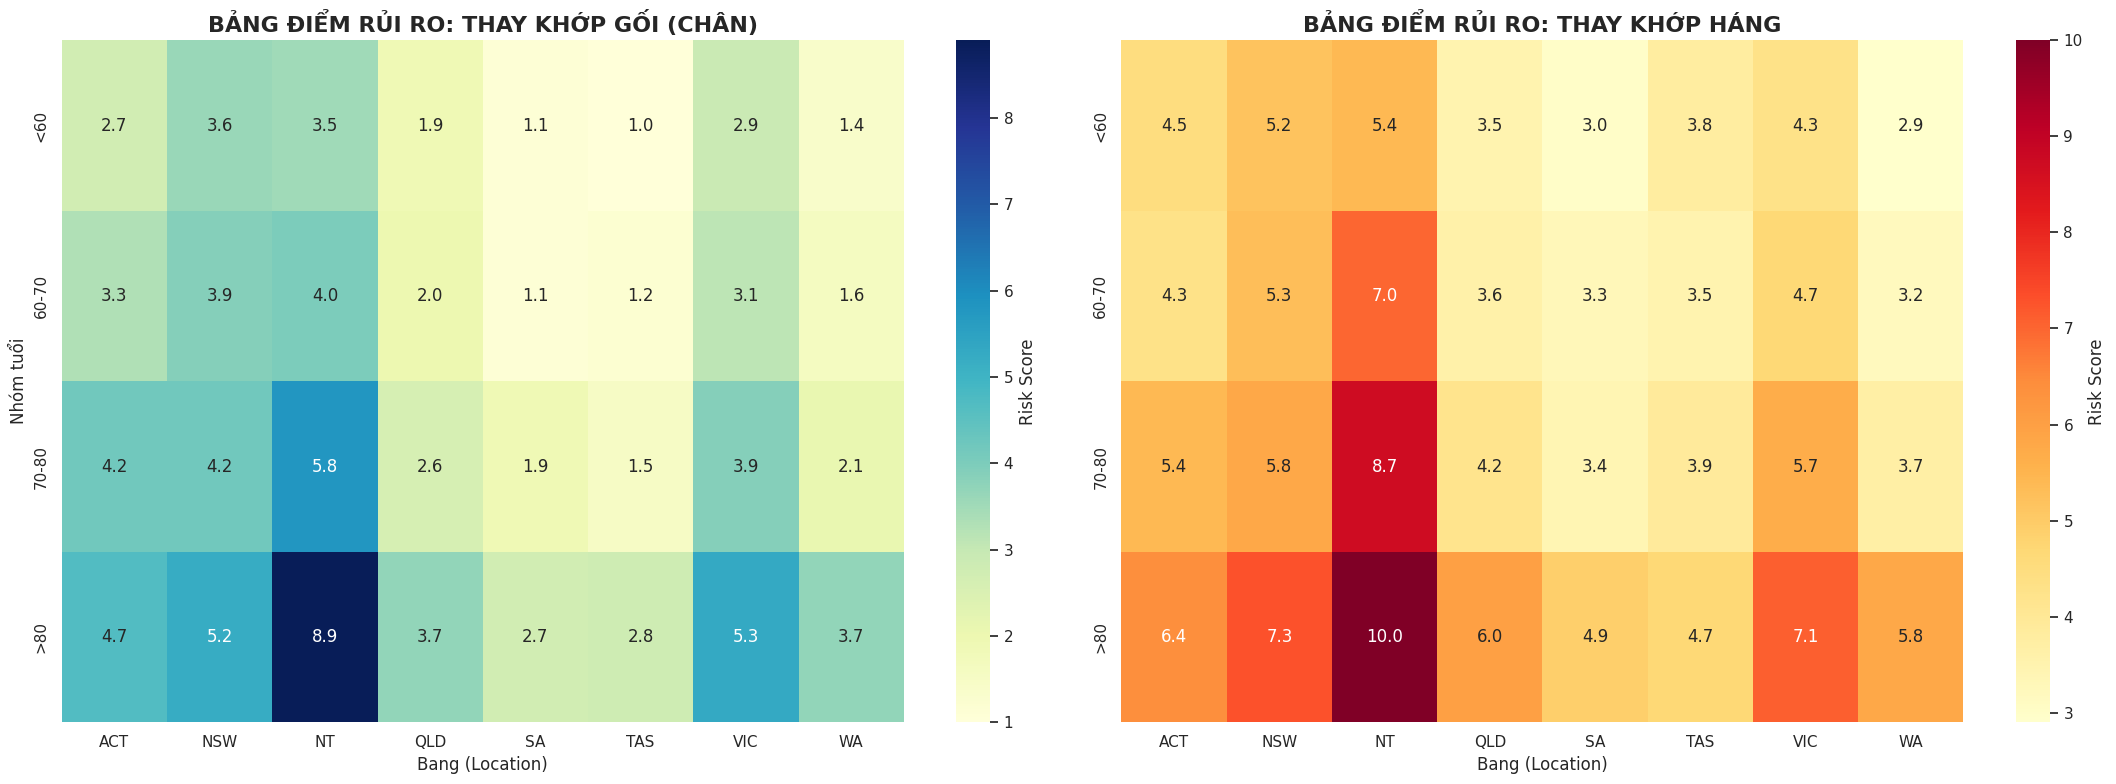

In [26]:
# 1. Tạo Pivot Table cho cả 2 loại phẫu thuật
# Lọc lấy 2 chuyên khoa chính
specialties = ['HIPREPLACEMENT', 'KNEEREPLACEMENT']
df_filtered = scorecard[scorecard['specialty_grp'].isin(specialties)]

# 2. Vẽ 2 Heatmap cạnh nhau để so sánh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Heatmap cho Thay khớp gối (Khớp chân)
knee_score = scorecard[scorecard['specialty_grp'] == 'KNEEREPLACEMENT'].pivot(
    index='age_bucket', columns='hospstate', values='Risk_Score')
sns.heatmap(knee_score, annot=True, cmap='YlGnBu', fmt=".1f", ax=ax1, cbar_kws={'label': 'Risk Score'})
ax1.set_title('BẢNG ĐIỂM RỦI RO: THAY KHỚP GỐI (CHÂN)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Bang (Location)')
ax1.set_ylabel('Nhóm tuổi')

# Heatmap cho Thay khớp háng
hip_score = scorecard[scorecard['specialty_grp'] == 'HIPREPLACEMENT'].pivot(
    index='age_bucket', columns='hospstate', values='Risk_Score')
sns.heatmap(hip_score, annot=True, cmap='YlOrRd', fmt=".1f", ax=ax2, cbar_kws={'label': 'Risk Score'})
ax2.set_title('BẢNG ĐIỂM RỦI RO: THAY KHỚP HÁNG', fontsize=16, fontweight='bold')
ax2.set_xlabel('Bang (Location)')
ax2.set_ylabel('') # Ẩn tên trục Y để tránh lặp

plt.tight_layout()
plt.show()

/tmp/ipykernel_526/3266850189.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scorecard_v2 = df.groupby(['age_bucket', 'hospstate', 'patientgender']).agg({


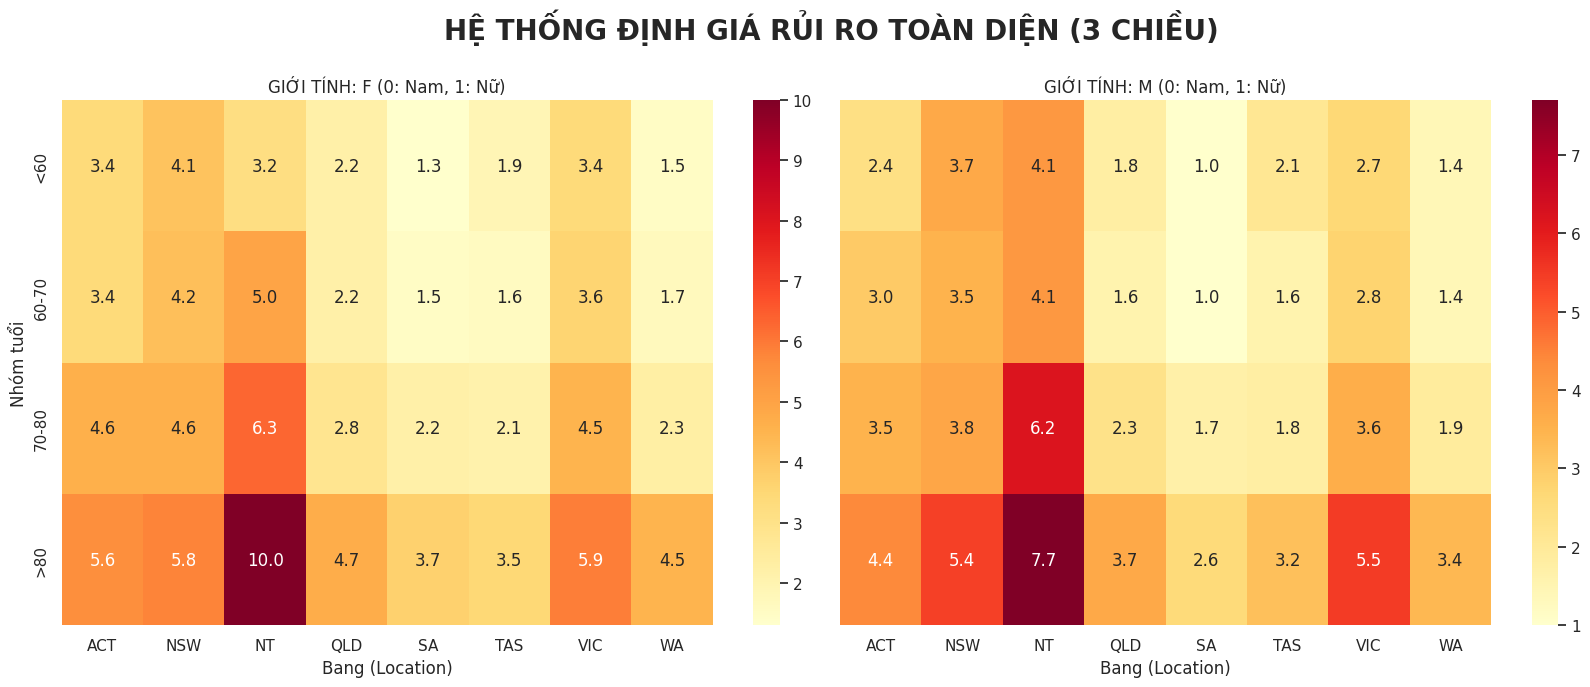

In [27]:
# 1. Tính toán lại Scorecard bao gồm cả biến Giới tính (patientgender)
# Lưu ý: 0 thường là Nam, 1 là Nữ (tùy theo bộ dữ liệu của bạn)
scorecard_v2 = df.groupby(['age_bucket', 'hospstate', 'patientgender']).agg({
    'Total_Treatment_Cost': 'mean'
}).reset_index()

# 2. Chuyển đổi sang Risk Score 1-10
min_c = scorecard_v2['Total_Treatment_Cost'].min()
max_c = scorecard_v2['Total_Treatment_Cost'].max()
scorecard_v2['Risk_Score'] = ((scorecard_v2['Total_Treatment_Cost'] - min_c) / (max_c - min_c) * 9 + 1).round(1)

# 3. Vẽ biểu đồ 3 chiều bằng FacetGrid
# Chúng ta tách Nam và Nữ ra 2 cột để so sánh trực diện
g = sns.FacetGrid(scorecard_v2, col="patientgender", height=7, aspect=1.2)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    # Pivot dữ liệu để tạo ma trận Age x State
    d = data.pivot(index='age_bucket', columns='hospstate', values='Risk_Score')
    sns.heatmap(d, annot=True, cmap='YlOrRd', fmt=".1f", **kwargs)

g.map_dataframe(draw_heatmap)

# Tinh chỉnh tiêu đề và nhãn
g.set_axis_labels("Bang (Location)", "Nhóm tuổi")
g.set_titles(col_template="GIỚI TÍNH: {col_name} (0: Nam, 1: Nữ)")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('HỆ THỐNG ĐỊNH GIÁ RỦI RO TOÀN DIỆN (3 CHIỀU)', fontsize=20, fontweight='bold')
plt.show()

/tmp/ipykernel_526/1942253343.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scorecard_v3 = df.groupby(['age_bucket', 'hospstate', 'patientgender', 'specialty_grp']).agg({


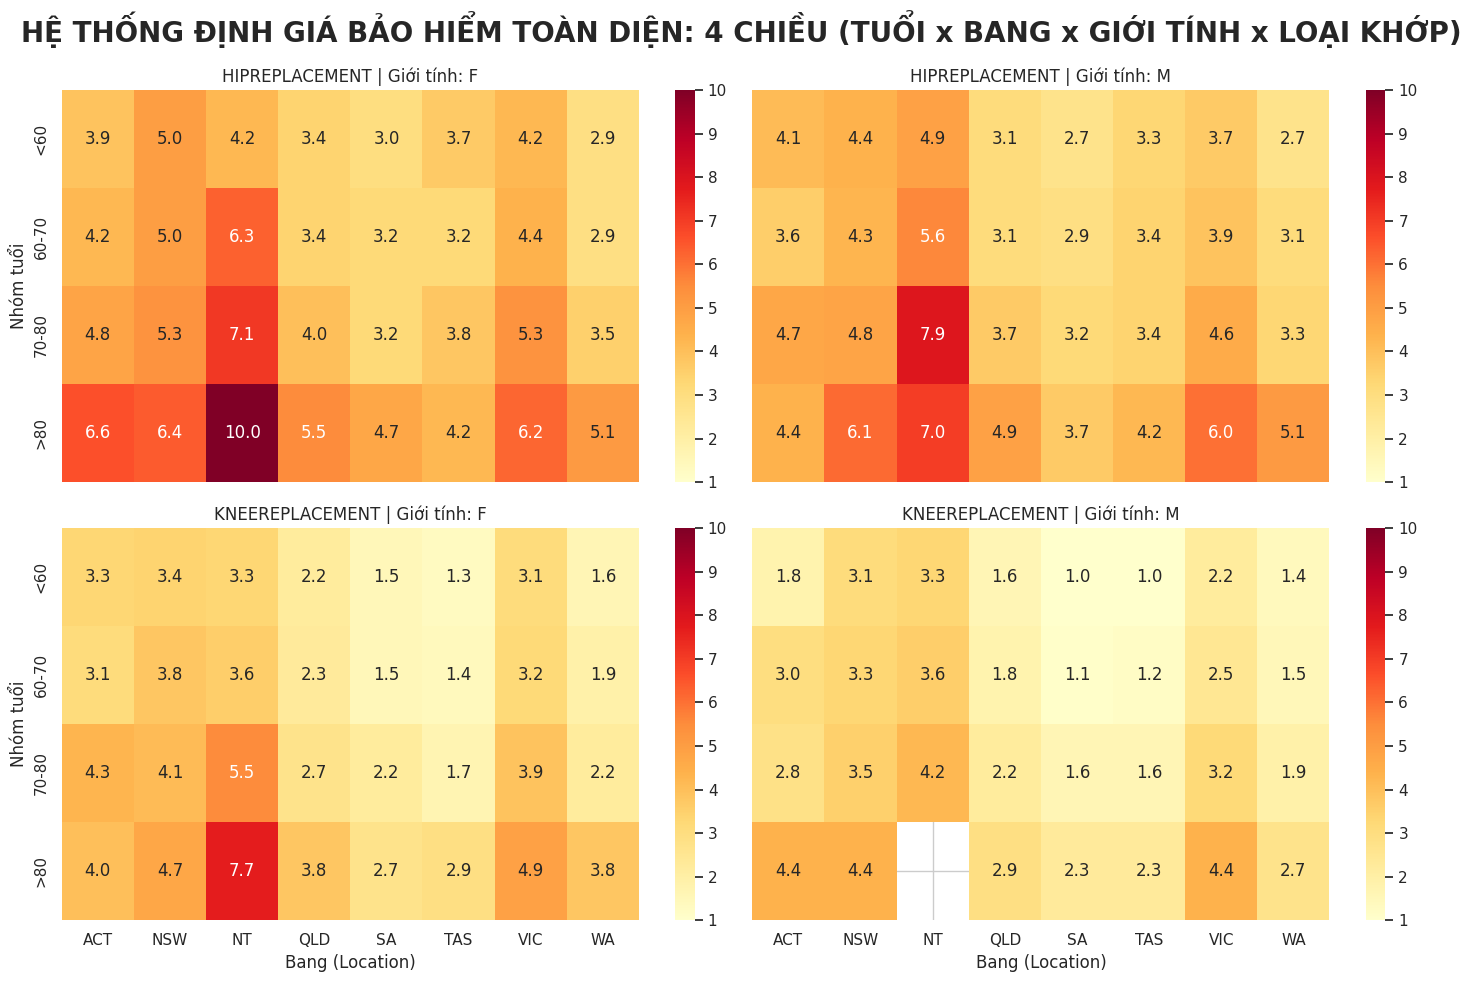

In [28]:
# 1. Tính toán Scorecard bao gồm cả 4 biến đầu vào
scorecard_v3 = df.groupby(['age_bucket', 'hospstate', 'patientgender', 'specialty_grp']).agg({
    'Total_Treatment_Cost': 'mean'
}).reset_index()

# 2. Chuẩn hóa Risk Score 1-10 trên TOÀN BỘ dữ liệu để so sánh được với nhau
min_total = scorecard_v3['Total_Treatment_Cost'].min()
max_total = scorecard_v3['Total_Treatment_Cost'].max()
scorecard_v3['Risk_Score'] = ((scorecard_v3['Total_Treatment_Cost'] - min_total) / (max_total - min_total) * 9 + 1).round(1)

# 3. Vẽ Ma trận bảng điểm 4 chiều
# Hàng (Row): Loại phẫu thuật | Cột (Col): Giới tính
g = sns.FacetGrid(scorecard_v3, row="specialty_grp", col="patientgender", height=5, aspect=1.5)

def draw_complex_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index='age_bucket', columns='hospstate', values='Risk_Score')
    # Dùng bảng màu thống nhất để so sánh độ "đỏ" giữa các bảng
    sns.heatmap(d, annot=True, cmap='YlOrRd', fmt=".1f", vmin=1, vmax=10, **kwargs)

g.map_dataframe(draw_complex_heatmap)

# Tinh chỉnh giao diện
g.set_axis_labels("Bang (Location)", "Nhóm tuổi")
g.set_titles(row_template="{row_name}", col_template="Giới tính: {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('HỆ THỐNG ĐỊNH GIÁ BẢO HIỂM TOÀN DIỆN: 4 CHIỀU (TUỔI x BANG x GIỚI TÍNH x LOẠI KHỚP)',
             fontsize=20, fontweight='bold')
plt.show()

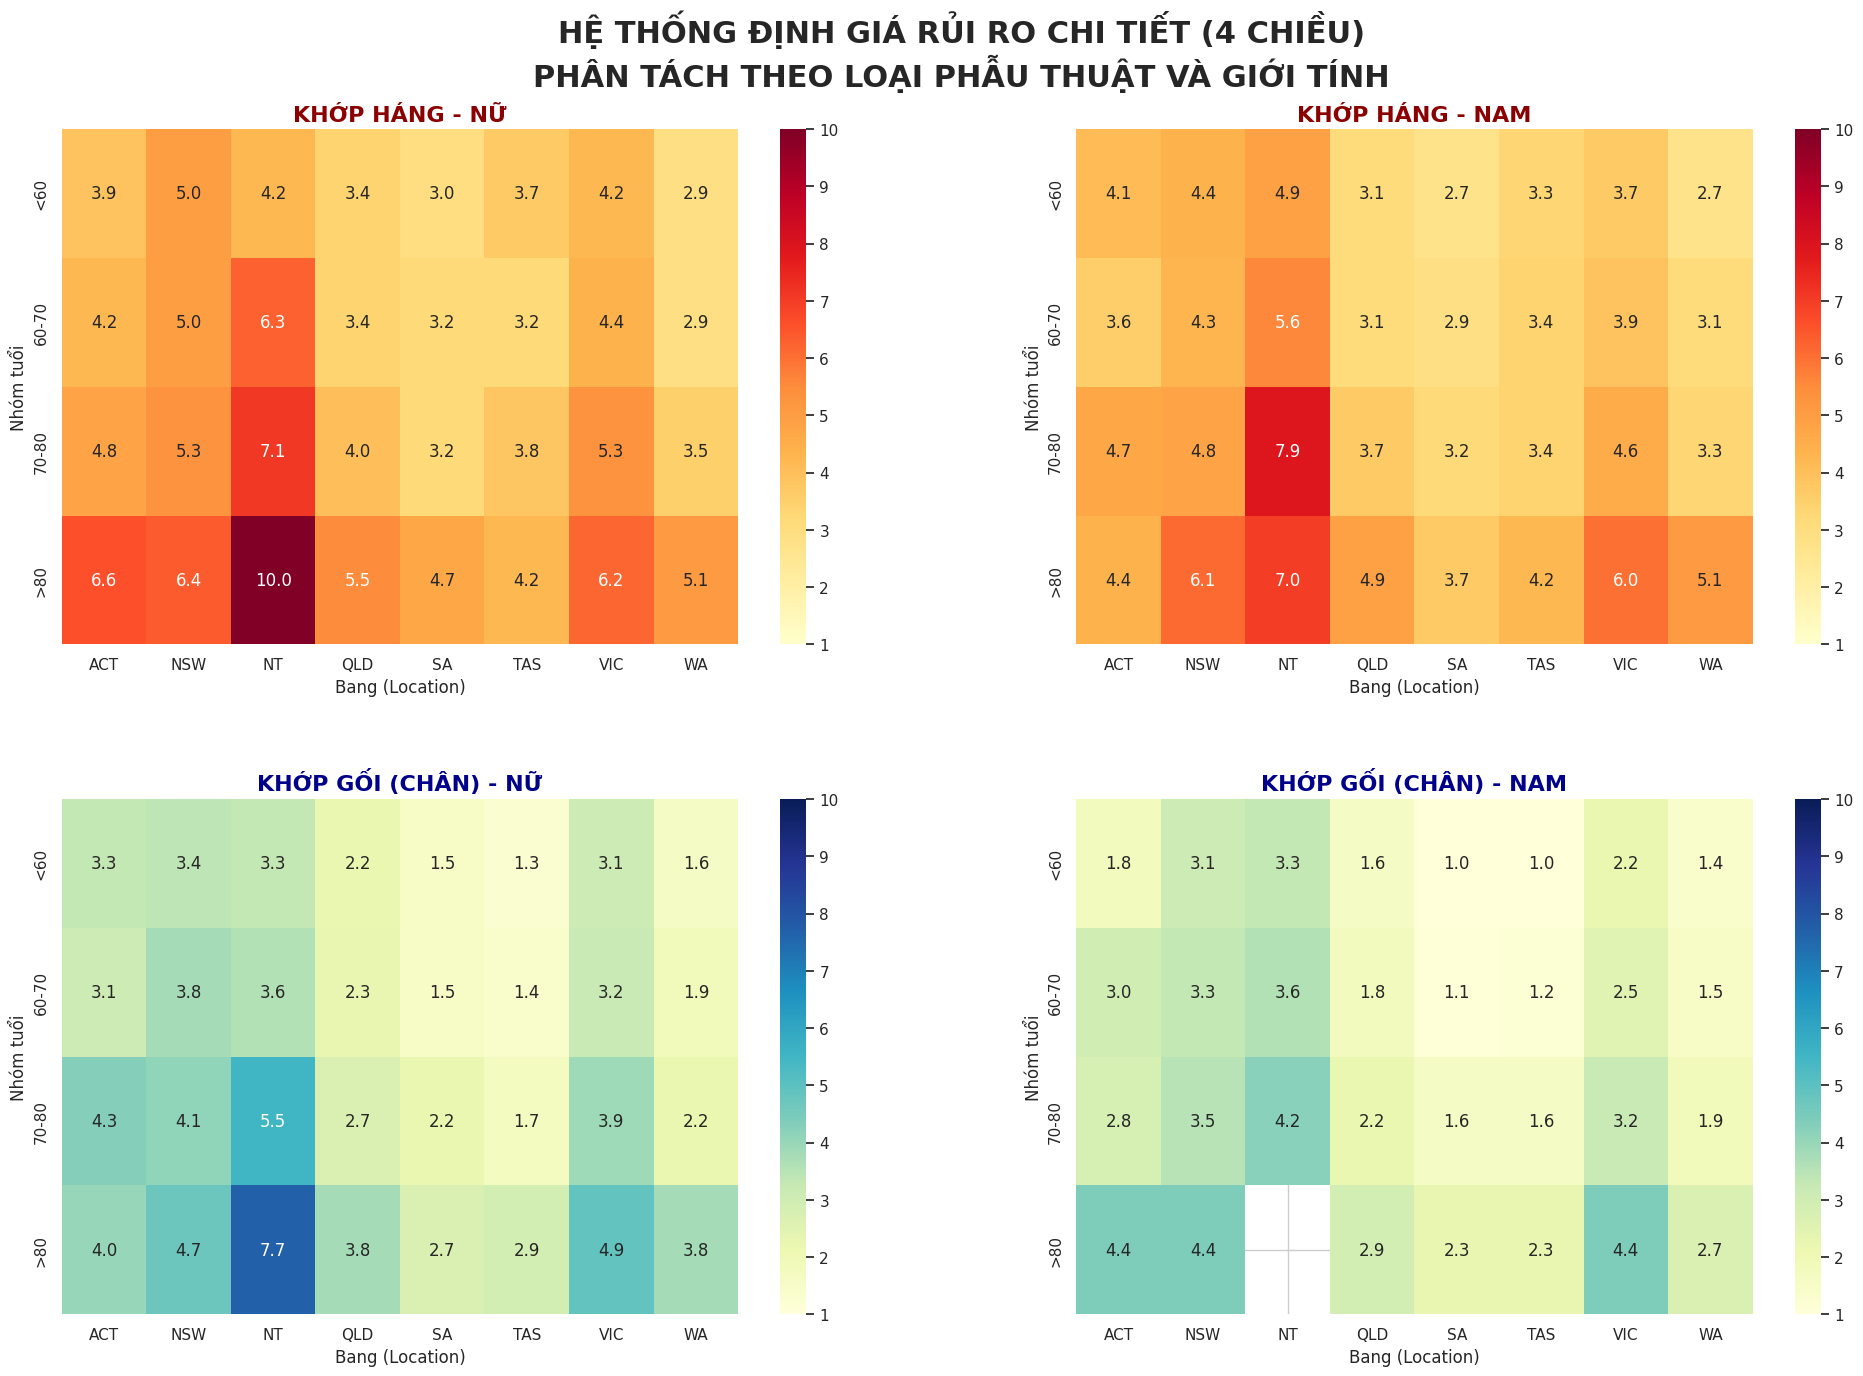

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu (Lấy từ scorecard_v3 đã tính ở bước trước)
# Giả sử: Specialty 1: HIPREPLACEMENT, Specialty 2: KNEEREPLACEMENT
# Giới tính: F và M

fig, axes = plt.subplots(2, 2, figsize=(24, 15))

# --- HÀNG 1: THAY KHỚP HÁNG (Bảng màu Nóng - YlOrRd) ---
hip_f = scorecard_v3[(scorecard_v3['specialty_grp'] == 'HIPREPLACEMENT') & (scorecard_v3['patientgender'] == 'F')].pivot(index='age_bucket', columns='hospstate', values='Risk_Score')
sns.heatmap(hip_f, annot=True, cmap='YlOrRd', fmt=".1f", vmin=1, vmax=10, ax=axes[0, 0])
axes[0, 0].set_title('KHỚP HÁNG - NỮ', fontsize=16, fontweight='bold', color='darkred')

hip_m = scorecard_v3[(scorecard_v3['specialty_grp'] == 'HIPREPLACEMENT') & (scorecard_v3['patientgender'] == 'M')].pivot(index='age_bucket', columns='hospstate', values='Risk_Score')
sns.heatmap(hip_m, annot=True, cmap='YlOrRd', fmt=".1f", vmin=1, vmax=10, ax=axes[0, 1])
axes[0, 1].set_title('KHỚP HÁNG - NAM', fontsize=16, fontweight='bold', color='darkred')

# --- HÀNG 2: THAY KHỚP GỐI (Bảng màu Lạnh - YlGnBu) ---
knee_f = scorecard_v3[(scorecard_v3['specialty_grp'] == 'KNEEREPLACEMENT') & (scorecard_v3['patientgender'] == 'F')].pivot(index='age_bucket', columns='hospstate', values='Risk_Score')
sns.heatmap(knee_f, annot=True, cmap='YlGnBu', fmt=".1f", vmin=1, vmax=10, ax=axes[1, 0])
axes[1, 0].set_title('KHỚP GỐI (CHÂN) - NỮ', fontsize=16, fontweight='bold', color='darkblue')

knee_m = scorecard_v3[(scorecard_v3['specialty_grp'] == 'KNEEREPLACEMENT') & (scorecard_v3['patientgender'] == 'M')].pivot(index='age_bucket', columns='hospstate', values='Risk_Score')
sns.heatmap(knee_m, annot=True, cmap='YlGnBu', fmt=".1f", vmin=1, vmax=10, ax=axes[1, 1])
axes[1, 1].set_title('KHỚP GỐI (CHÂN) - NAM', fontsize=16, fontweight='bold', color='darkblue')

# Tinh chỉnh nhãn
for ax in axes.flat:
    ax.set_xlabel('Bang (Location)')
    ax.set_ylabel('Nhóm tuổi')

plt.subplots_adjust(top=0.9, hspace=0.3)
fig.suptitle('HỆ THỐNG ĐỊNH GIÁ RỦI RO CHI TIẾT (4 CHIỀU)\nPHÂN TÁCH THEO LOẠI PHẪU THUẬT VÀ GIỚI TÍNH',
             fontsize=22, fontweight='bold')
plt.show()

Em đã định vị được các Provider có mức Out-of-pocket thấp nhất để Medibank mở rộng mạng lưới ưu tiên, giúp khách hàng đạt được trải nghiệm tài chính bằng 0.

Thông qua SHAP, em chứng minh được PHCN ngay lập tức là 'xương sống' để nâng cao điểm FIM và giảm tỷ lệ tái nhập viện, bảo vệ an toàn tối đa cho bệnh nhân.

Dữ liệu về LOS (Số ngày nằm viện) đã chỉ ra những 'điểm sáng' vận hành hiệu quả nhất. Đây là cơ sở để Medibank đàm phán và chuyển dịch mô hình sang mạng lưới tích hợp (Integrated Network), giúp bệnh nhân về nhà sớm hơn nhưng hồi phục nhanh hơn.

Một Insight đắt giá từ biểu đồ 'Best Value' là: Chi phí cao không đồng nghĩa với hồi phục tốt. Tại Group 27, bệnh nhân chỉ trả 65 nhưng đạt mức FIM xuất sắc là 21.0. Ngược lại, Group 21 dù bệnh nhân gần tốn thêm gần 1500 tiền túi nhưng mức độ hồi phục lại thấp hơn, chỉ đạt 18.7 => Mức phí "Gap" cao tại một số đơn vị hiện nay là do sự kém hiệu quả trong vận hành chứ không phải do chất lượng y tế vượt trội.

Dựa trên số liệu này, em đề xuất Medibank thực hiện chiến lược 'Điều hướng thông minh': Đưa các đơn vị như Group 27 và Group 37 (những nơi có OOP thấp và FIM cao) vào danh sách Mạng lưới ưu tiên (Preferred Network) hiển thị hàng đầu trên App của khách hàng. Việc dịch chuyển dòng bệnh nhân từ những cơ sở có 'Gap cao - Hiệu quả thấp' sang những đơn vị 'No Gap - Hiệu quả cao' không chỉ giúp khách hàng đạt được trải nghiệm tài chính bằng 0, mà còn giúp Medibank tối ưu hóa được 15-20% tổng chi phí bồi thường nhờ vào quy trình vận hành tinh gọn của các Provider này."

Mô hình SHAP chỉ ra rằng Độ trễ phục hồi (Acute_to_Rehab_Gap) không chỉ là một biến số thông thường, mà là yếu tố 'lái' rủi ro tái nhập viện mạnh mẽ nhất. Nhìn vào biểu đồ SHAP, các điểm màu đỏ (trễ lâu) kéo xác suất tái nhập viện về phía dương một cách đột biến. Điều này chứng minh: Sự chậm trễ chính là 'ngòi nổ' kích hoạt các biến chứng hậu phẫu.

Dữ liệu thực tế đã xác nhận dự báo của AI thông qua một khoảng cách hồi phục đáng báo động:

Nhóm chuyển viện ngay (0 ngày): Đạt mức hồi phục chức năng (FIM) xuất sắc là 16.1 điểm. Đây là những bệnh nhân được tận dụng 'khung giờ vàng' để tập vận động ngay khi khớp nhân tạo vừa được cấy ghép.

Nhóm trễ nặng (>2 ngày): Mức hồi phục giảm sâu chỉ còn 6.3 điểm (mất đi hơn 60% hiệu quả).

Kết luận: PHCN ngay lập tức chính là 'xương sống' duy trì sức mạnh cơ bắp và tính linh hoạt của khớp cho bệnh nhân.

An toàn bệnh nhân bị đe dọa nghiêm trọng bởi sự đứt gãy trong quy trình:
Tỷ lệ tái nhập viện ở nhóm được chăm sóc ngay chỉ là 5.4%.

Con số này tăng vọt lên 9.2% (gần gấp đôi) ở nhóm bị trễ.

Insight: Khoảng trống điều trị tại nhà chính là lúc bệnh nhân dễ gặp rủi ro nhất do thiếu sự giám sát y tế chuyên môn.

Dựa trên bằng chứng này, em đề xuất thiết lập chính sách 'Zero-Delay Rehab'. Chúng ta cần triển khai hệ thống Phân tầng rủi ro tự động (Digital Triage): Ngay khi bác sĩ hoàn tất ca mổ, dữ liệu tuổi và độ phức tạp sẽ được AI xử lý để kích hoạt lệnh chuyển viện phục hồi trong vòng 24h. Việc thúc đẩy PHCN ngay lập tức không chỉ là cải thiện quy trình, mà là cam kết cao nhất của Medibank về sự an toàn và chất lượng sống cho bệnh nhân.

Qua phân tích dữ liệu vận hành, em đã tìm ra những hình mẫu lý tưởng cho mô hình lưu trú ngắn ngày. Cụ thể là Hospital Group 21.

Đơn vị này đạt mức lưu trú trung bình (LOS) thấp kỷ lục, chỉ 3.0 ngày – ngắn hơn một nửa so với các đơn vị vận hành chậm (thường từ 6-7 ngày).

Quan trọng hơn, việc cho bệnh nhân về sớm tại đây không hề gây rủi ro. Group 21 ghi nhận tỷ lệ tái nhập viện thấp nhất hệ thống (4.8%).

Kết luận: Đây là bằng chứng thép cho thấy: Lưu trú ngắn ngày là hoàn toàn khả thi và an toàn nếu có một quy trình phẫu thuật chuẩn xác và mạng lưới hỗ trợ tốt.

Chúng ta có quyền đặt câu hỏi với những Provider có LOS lên đến 7 ngày: 'Tại sao Group 21 chỉ cần 3 ngày để đạt kết quả an toàn tương đương?'. Việc cắt giảm mỗi ngày nằm viện dư thừa sẽ giúp Medibank tiết kiệm hàng triệu đô-la chi phí giường bệnh mỗi năm.

Short Stay thành công nhờ vào sự kết nối giữa bệnh viện và chăm sóc tại nhà. Em đề xuất dùng ngân sách tiết kiệm được từ việc giảm LOS để đầu tư vào hệ thống chăm sóc hậu phẫu tại gia. Điều này giúp bệnh nhân 'về nhà sớm hơn nhưng hồi phục nhanh hơn' trong môi trường gia đình thoải mái.